# Detecting Card Transactions Fraud with Machine Learning
- Classification
- Anomaly Detection
- **주제**: 카드 사기로 인한 손실과 사기 탐지 시스템 운영 비용의 최소화를 위한 머신러닝 모델 개발.
- **목표**: 데이터를 변수의 확률/통계, 가시화 등 다각적으로 분석하여 머신러닝 모델을 제안하고 검증함.
- **내용**
  - 데이터 분석, 가시화를 통한 분석
  - 선형 분류 모델의 이해 및 구현
  - PCA, EM 군집화 algorithm 등을 활용하여 feature selection 혹은 추론
  - Logistic regression, tree 구조, 모델의 설명성 등을 활용하여 feature selection 혹은 추론
  - 결측값  등의 데이터 전처리
  - 신경망 (Neural Network)구조는 활용 금지.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 01. 데이터 준비를 위한 EDA 및 전처리

### 1. 데이터 불러오기

In [3]:
############################################## 00. 필요한 파이썬 라이브러리 불러오기 #####################################################
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# Plotly
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

from sklearn.model_selection import train_test_split

import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.svm import OneClassSVM

from scipy.stats import pearsonr, chi2_contingency
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [5]:
# train 데이터
data = pd.read_csv('/content/drive/MyDrive/Data.csv')
data.head()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,...,Card Number,Expires,Has Chip,Credit Limit,Acct Open Date,Year PIN last Changed,Amount,Whether Security Chip is Used,Error Message,Is Fraud?
0,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,84600.0,0,NaN,No
1,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,72100.0,0,NaN,No
2,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,3300.0,1,NaN,No
3,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,56800.0,0,NaN,No
4,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,104600.0,0,NaN,No


In [ ]:
# 사용자 정보
data.iloc[:, :11].head()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,Credit Score
0,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,779
1,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,779
2,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,779
3,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,779
4,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,779


In [ ]:
# 카드 정보
data.iloc[:, 11:20]

,Year,Month,Day,Merchandise Code,Card,Card Brand,Card Type,Card Number,Expires
0,2018,1,2,5912,0,Visa,Debit,5.655323e+15,12/2022
1,2018,1,5,5411,0,Visa,Debit,5.655323e+15,12/2022
2,2018,1,5,5815,0,Visa,Debit,5.655323e+15,12/2022
3,2018,1,6,5411,0,Visa,Debit,5.655323e+15,12/2022
4,2018,1,11,5541,0,Visa,Debit,5.655323e+15,12/2022
...,...,...,...,...,...,...,...,...,...
1644763,2018,12,30,7538,1,Visa,Credit,5.005989e+15,12/2020
1644764,2018,12,30,4121,1,Visa,Credit,5.005989e+15,12/2020
1644765,2018,12,31,5311,1,Visa,Credit,5.005989e+15,12/2020
1644766,2018,12,31,7538,1,Visa,Credit,5.005989e+15,12/2020


In [ ]:
# 거래 정보
data.iloc[:, 20:25]

,Has Chip,Credit Limit,Acct Open Date,Year PIN last Changed,Amount
0,True,14455525,09/2002,2008,84600.0
1,True,14455525,09/2002,2008,72100.0
2,True,14455525,09/2002,2008,3300.0
3,True,14455525,09/2002,2008,56800.0
4,True,14455525,09/2002,2008,104600.0
...,...,...,...,...,...
1644763,True,8568000,05/2017,2017,25500.0
1644764,True,8568000,05/2017,2017,17900.0
1644765,True,8568000,05/2017,2017,2700.0
1644766,True,8568000,05/2017,2017,45500.0


In [ ]:
# 보안 및 사기 관련
data.iloc[:, 25:28]

,Whether Security Chip is Used,Error Message,Is Fraud?
0,0,NaN,No
1,0,NaN,No
2,1,NaN,No
3,0,NaN,No
4,0,NaN,No
...,...,...,...
1644763,0,NaN,No
1644764,1,NaN,No
1644765,1,NaN,No
1644766,0,NaN,No


In [ ]:
data.shape

(1644768, 28)

In [6]:
# test 데이터
test_data = pd.read_csv('/content/drive/MyDrive/test_submission.csv')
test_data.head()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,...,Card Type,Card Number,Expires,Has Chip,Credit Limit,Acct Open Date,Year PIN last Changed,Amount,Whether Security Chip is Used,Error Message
0,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,Debit,5.655323e+15,12/2022,True,14455525,09/2002,2008,98900.0,0,Insufficient Balance
1,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,Debit,5.655323e+15,12/2022,True,14455525,09/2002,2008,35700.0,0,NaN
2,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,Debit,5.655323e+15,12/2022,True,14455525,09/2002,2008,62800.0,0,NaN
3,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,Debit,5.655323e+15,12/2022,True,14455525,09/2002,2008,9900.0,0,NaN
4,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,Debit,5.655323e+15,12/2022,True,14455525,09/2002,2008,87100.0,0,NaN


In [ ]:
test_data.shape

(1698418, 27)

### 2. 데이터 탐색
1. 데이터 개요:
   이 데이터셋은 카드 거래 정보와 사용자 정보를 포함하며, 사기 탐지를 위한 머신러닝 프로젝트에 활용 되기 위해 익명화 되었습니다.


2. 데이터 구조:
   총 30개의 컬럼으로 구성되어 있으며, 사용자 정보, 카드 정보, 거래 정보 등을 포함합니다.


3. 주요 특성 설명:

   a) 사용자 정보:
      - User (int64): 사용자 고유 식별자
      - Gender (int64): 성별
      - Current Age (int64): 현재 나이
      - Retirement Age (int64): 은퇴 나이
      - Birth Year (int64): 출생 연도
      - Birth Month (int64): 출생 월
      - Zipcode (float64): 행정 구역 우편번호
      - Per Capita Income - Zipcode (float64): 우편번호 행정 구역 기준 1인당 소득
      - Yearly Income (float64): 연간 소득
      - Total Debt (float64): 총 부채
      - Credit Score (int64): 신용 점수

   b) 카드 정보:
      - Card (int64): 카드 식별자
      - Card Brand (object): 카드 브랜드
      - Card Type (object): 카드 유형
      - Card Number (float64): 카드 번호
      - Expires (object): 카드 만료일
      - Has Chip (bool): 보안 칩 탑재 여부
      - Credit Limit (int64): 신용 한도
      - Acct Open Date (object): 계좌 개설일
      - Year PIN Last Changed (int64): 보안 비밀번호 마지막 변경 연도

   c) 거래 정보:
      - Year (int64): 거래 연도
      - Month (int64): 거래 월
      - Day (int64): 거래 일
      - Amount (float64): 거래 금액
      - Merchandise Code (int64): 상품 코드

   d) 보안 및 사기 관련:
      - Whether Security Chip is Used (int64): 보안 칩 사용 여부
      - Error Message (object): 오류 메시지
      - Is Fraud? (object): 사기 여부 (정답)

#### 1) 데이터 타입

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1644768 entries, 0 to 1644767
Data columns (total 28 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   User                           1644768 non-null  int64  
 1   Gender                         1644768 non-null  int64  
 2   Current Age                    1644768 non-null  int64  
 3   Retirement Age                 1644768 non-null  int64  
 4   Birth Year                     1644768 non-null  int64  
 5   Birth Month                    1644768 non-null  int64  
 6   Zipcode                        1644768 non-null  float64
 7   Per Capita Income - Zipcode    1644768 non-null  int64  
 8   Yearly Income                  1644768 non-null  float64
 9   Total Debt                     1644768 non-null  float64
 10  Credit Score                   1644768 non-null  int64  
 11  Year                           1644768 non-null  int64  
 12  Month         

#### 2) 데이터 통계값

In [ ]:
data.describe()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,...,Year,Month,Day,Merchandise Code,Card,Card Number,Credit Limit,Year PIN last Changed,Amount,Whether Security Chip is Used
count,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,...,1644768.0,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06,1.644768e+06
mean,1.004376e+03,4.835892e-01,5.229045e+01,6.637021e+01,1.966894e+03,6.519760e+00,4.988484e+04,1.425004e+07,2.792330e+07,3.623609e+07,...,2018.0,6.558884e+00,1.573131e+01,5.554929e+03,1.273811e+00,5.163251e+15,9.160743e+06,2.011822e+03,2.534947e+04,4.642527e-01
std,5.695082e+02,4.997308e-01,1.622627e+01,3.570074e+00,1.621924e+01,3.575366e+00,2.965987e+04,6.912591e+06,1.552382e+07,3.406705e+07,...,0.0,3.446594e+00,8.798610e+00,8.810854e+02,1.369525e+00,1.289868e+15,7.107103e+06,3.052586e+00,5.458708e+04,7.668795e-01
min,0.000000e+00,0.000000e+00,2.000000e+01,5.000000e+01,1.918000e+03,1.000000e+00,4.920000e+02,0.000000e+00,5.000000e+02,0.000000e+00,...,2018.0,1.000000e+00,1.000000e+00,1.711000e+03,0.000000e+00,3.005502e+15,0.000000e+00,2.002000e+03,-7.408000e+05,0.000000e+00
25%,5.170000e+02,0.000000e+00,4.000000e+01,6.500000e+01,1.957000e+03,3.000000e+00,2.265400e+04,1.017688e+07,1.834940e+07,1.014754e+07,...,2018.0,4.000000e+00,8.000000e+00,5.300000e+03,0.000000e+00,4.420395e+15,4.641000e+06,2.010000e+03,3.500000e+03,0.000000e+00
50%,1.010000e+03,0.000000e+00,5.000000e+01,6.600000e+01,1.969000e+03,7.000000e+00,5.387600e+04,1.262530e+07,2.457150e+07,3.117703e+07,...,2018.0,7.000000e+00,1.600000e+01,5.499000e+03,1.000000e+00,4.894334e+15,8.032500e+06,2.011000e+03,1.400000e+04,0.000000e+00
75%,1.479000e+03,1.000000e+00,6.200000e+01,6.800000e+01,1.979000e+03,1.000000e+01,7.229600e+04,1.641546e+07,3.386700e+07,5.165649e+07,...,2018.0,1.000000e+01,2.300000e+01,5.812000e+03,2.000000e+00,5.504827e+15,1.229270e+07,2.014000e+03,3.590000e+04,1.000000e+00
max,1.999000e+03,1.000000e+00,1.010000e+02,7.900000e+01,1.999000e+03,1.200000e+01,9.889300e+04,9.707128e+07,1.578132e+08,3.171627e+08,...,2018.0,1.200000e+01,3.100000e+01,9.402000e+03,8.000000e+00,9.699390e+15,8.412764e+07,2.020000e+03,2.936700e+06,2.000000e+00


#### 3) 결측값

In [ ]:
# 결측값이 있는지 여부
data.isnull().any().any()

True

#### 4) 중복값

In [7]:
# 중복된 행의 개수
print("중복된 항목 수 :", len(data[data.duplicated()]))

중복된 항목 수 : 1369


### 3. 데이터 타입별 Feature 변환

#### 1) 범주형 데이터 확인

In [ ]:
data.select_dtypes('object').head()

,Card Brand,Card Type,Expires,Acct Open Date,Error Message,Is Fraud?
0,Visa,Debit,12/2022,09/2002,NaN,No
1,Visa,Debit,12/2022,09/2002,NaN,No
2,Visa,Debit,12/2022,09/2002,NaN,No
3,Visa,Debit,12/2022,09/2002,NaN,No
4,Visa,Debit,12/2022,09/2002,NaN,No


#### 2) 범주형 데이터 중 날짜 데이터 처리

In [8]:
data['Expires'] = pd.to_datetime(data['Expires'], format='%m/%Y')
data['Acct Open Date'] = pd.to_datetime(data['Acct Open Date'], format='%m/%Y')

In [9]:
# 'Expires' 칼럼에서 연도와 월 추출
data['Expires_Year'] = data['Expires'].dt.year
data['Expires_Month'] = data['Expires'].dt.month

# 'Acct Open Date' 칼럼에서 연도와 월 추출
data['AcctOpen_Year'] = data['Acct Open Date'].dt.year
data['AcctOpen_Month'] = data['Acct Open Date'].dt.month

data = data.drop(columns=['Expires', 'Acct Open Date'])

In [ ]:
data.head()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,...,Credit Limit,Year PIN last Changed,Amount,Whether Security Chip is Used,Error Message,Is Fraud?,Expires_Year,Expires_Month,AcctOpen_Year,AcctOpen_Month
0,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,14455525,2008,84600.0,0,NaN,No,2022,12,2002,9
1,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,14455525,2008,72100.0,0,NaN,No,2022,12,2002,9
2,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,14455525,2008,3300.0,1,NaN,No,2022,12,2002,9
3,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,14455525,2008,56800.0,0,NaN,No,2022,12,2002,9
4,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,14455525,2008,104600.0,0,NaN,No,2022,12,2002,9


### 4. 결측값 처리
- 결측값 처리
- 기준 정보 데이터와 카드 거래 정보 데이터의 정합성 맞추기

#### 1) 컬럼별 결측값 비율 구한 후, 비율=1 인 컬럼 제거
  * .isna().mean()
  * 컬럼별 결측값 비율이 0 인 항목을 제외한 나머지 항목들을 pandas 의 sort_values() 사용하여 정렬
  * 비율=1 인 항목을 확인하여 pandas의 drop으로 제거

In [ ]:
data.isna().mean()

,0
User,0.000000
Gender,0.000000
Current Age,0.000000
Retirement Age,0.000000
Birth Year,0.000000
Birth Month,0.000000
Zipcode,0.000000
Per Capita Income - Zipcode,0.000000
Yearly Income,0.000000
Total Debt,0.000000


In [ ]:
nan_mean = data.isna().mean()
nan_mean = nan_mean[nan_mean != 0].sort_values()
nan_mean

,0
Error Message,0.984335


- Error Message 칼럼이 유일하게 결측값이 있으며 대부분이 결측값이므로 의미가 없어 제거

In [10]:
data = data.drop(['Error Message'], axis=1, errors='ignore')

- 그 외 칼럼에서 결측값이 없으므로 추가적인 결측값 처리는 필요없다.

### 5. 변수 간 상관성에 따른 데이터 정제

#### 1) 숫자형 컬럼 데이터의 유일한 값 개수 확인
- pandas 의 select_dtypes('number') 사용
- pandas 의 nunique().sort_values() 사용
- 유일한 값이 1개인 경우/모든 행의 값이 다른 경우 둘 다 제거한다

In [11]:
num_feat = data.select_dtypes('number').columns.values
data[num_feat].nunique().sort_values()

,0
Year,1
Gender,2
Whether Security Chip is Used,3
Expires_Year,5
Card,9
Expires_Month,12
Month,12
Birth Month,12
AcctOpen_Month,12
Year PIN last Changed,19


- `Year`는 하나만 있으므로 제거
- 'Gender'와 같은 범주형 칼럼은 사실 object이나, number로 표현되어 있으므로 유지
- `User`, `Card`는 1509명에 대한 고유 ID 이므로 제거

In [12]:
data = data.drop(['Year', 'User', 'Card'], axis=1, errors='ignore')

#### 2) 숫자형 데이터 상관도에 따른 컬럼 제거
  * 숫자형 컬럼들 간 Pearson R 상관 계수를 구한다
  * 상관 계수가 0.9 이상인 컬럼들 중 가장 큰 컬럼을 제거해 본다
  * 컬럼들 간 조합 생성 : comb_num_feat = np.array(list(combinations(num_feat, 2)))
  * Pearson R 상관 계수 구하기 : pearsonr(x1, x2)[0]

In [13]:
num_feat = data.select_dtypes('number').columns.values
comb_num_feat = np.array(list(combinations(num_feat, 2)))
corr_num_feat = np.array([])
for comb in comb_num_feat:
    corr = pearsonr(data[comb[0]], data[comb[1]])[0]
    corr_num_feat = np.append(corr_num_feat, corr)

In [14]:
high_corr_num = comb_num_feat[np.abs(corr_num_feat) >= 0.9]
high_corr_num

array([['Current Age', 'Birth Year']], dtype='<U29')

In [15]:
data = data.drop(np.unique(high_corr_num[:, 0]), axis=1, errors='ignore')

#### 3) 범주형 데이터의 유일한 값 개수 확인
  * pandas 의 select_dtypes('object') 사용
  * pandas 의 nunique().sort_values() 사용
  * 유일한 값이 1개인 경우/모든 행의 값이 다른 경우 둘 다 제거한다
  * 범주형 데이터의 경우 Encoding 시 메모리 오류를 방지하기 위해 유일한 값이 많은 경우는 제거하는 것이 좋다

In [ ]:
cat_feat = data.select_dtypes('object').columns.values
data[cat_feat].nunique().sort_values()

,0
Is Fraud?,2
Card Brand,3
Card Type,3


- 특별히 너무 많거나 고유한 범주형 데이터가 없으므로 넘어간다

#### 4) 범주형 데이터 상관도에 따른 컬럼 제거
  * 범주형 컬럼들 간 카이제곱 통계량을 사용하는 Crammer 의 V 상관 계수를 구한다
  * Crammer 의 V 상관계수 식 구하는 방법


```
  table = pd.pivot_table(X, values='Amount', index=comb[0], columns=comb[1], aggfunc='count').fillna(0)
  corr = np.sqrt(chi2_contingency(table)[0] / (table.values.sum() * (np.min(table.shape) - 1) ) )
```


  * 상관 계수가 0.9 이상인 컬럼들 중 머신러닝 모델 생성 시 예측 변수의 조건으로 활용할 grade 를 제외한 후 가장 높은 컬럼을 제거한다.
  * 컬럼들 간 조합 생성 : comb_cat_feat = np.array(list(combinations(cat_feat, 2)))

In [16]:
cat_feat = data.select_dtypes('object').columns.values
comb_cat_feat = np.array(list(combinations(cat_feat, 2)))
corr_cat_feat = np.array([])
for comb in comb_cat_feat:
    table = pd.pivot_table(data, values='Amount', index=comb[0], columns=comb[1], aggfunc='count').fillna(0)
    corr = np.sqrt(chi2_contingency(table)[0] / (table.values.sum() * (np.min(table.shape) - 1) ) )
    corr_cat_feat = np.append(corr_cat_feat, corr)

In [17]:
high_corr_cat = comb_cat_feat[corr_cat_feat >= 0.9]
high_corr_cat

array([], shape=(0, 2), dtype='<U10')

- 범주형 데이터를 One Hot Encoding으로 수치형으로 변경한다.

In [18]:
data = pd.get_dummies(data, columns=['Card Brand', 'Card Type'])

In [19]:
# Is Fraud? 칼럼 또한 수치형으로 변경
data['Is Fraud?'] = data['Is Fraud?'].map({'Yes': 1, 'No': 0})

In [20]:
# Is Fraud 칼럼을 pop한 후 다시 concat하여 맨 뒤로 보내기
is_fraud = data.pop('Is Fraud?')
data['Is Fraud?'] = is_fraud

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1644768 entries, 0 to 1644767
Data columns (total 29 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   Gender                         1644768 non-null  int64  
 1   Retirement Age                 1644768 non-null  int64  
 2   Birth Year                     1644768 non-null  int64  
 3   Birth Month                    1644768 non-null  int64  
 4   Zipcode                        1644768 non-null  float64
 5   Per Capita Income - Zipcode    1644768 non-null  int64  
 6   Yearly Income                  1644768 non-null  float64
 7   Total Debt                     1644768 non-null  float64
 8   Credit Score                   1644768 non-null  int64  
 9   Month                          1644768 non-null  int64  
 10  Day                            1644768 non-null  int64  
 11  Merchandise Code               1644768 non-null  int64  
 12  Card Number   

### 6. Target Feature 정의



In [ ]:
data['Is Fraud?'].unique()

array([0, 1])

##### 1) Pie Chart

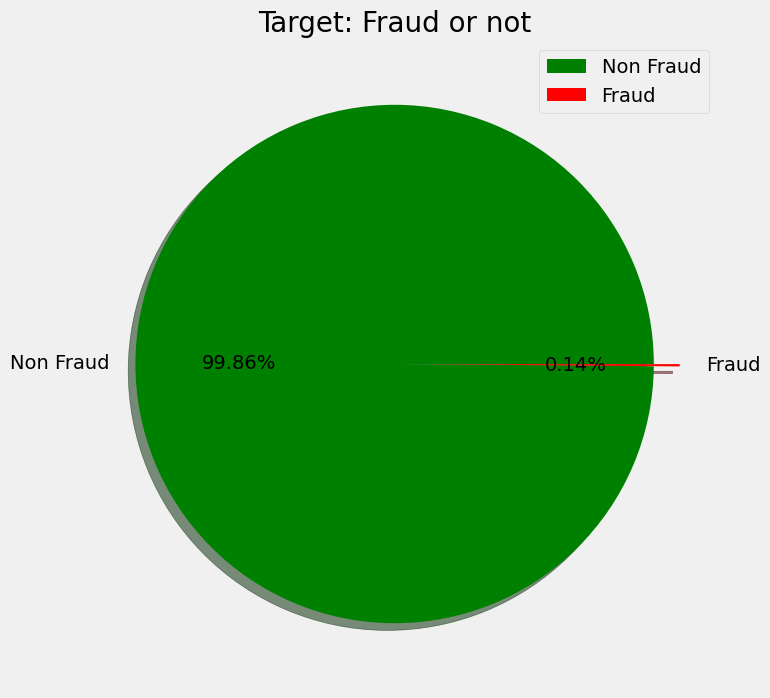

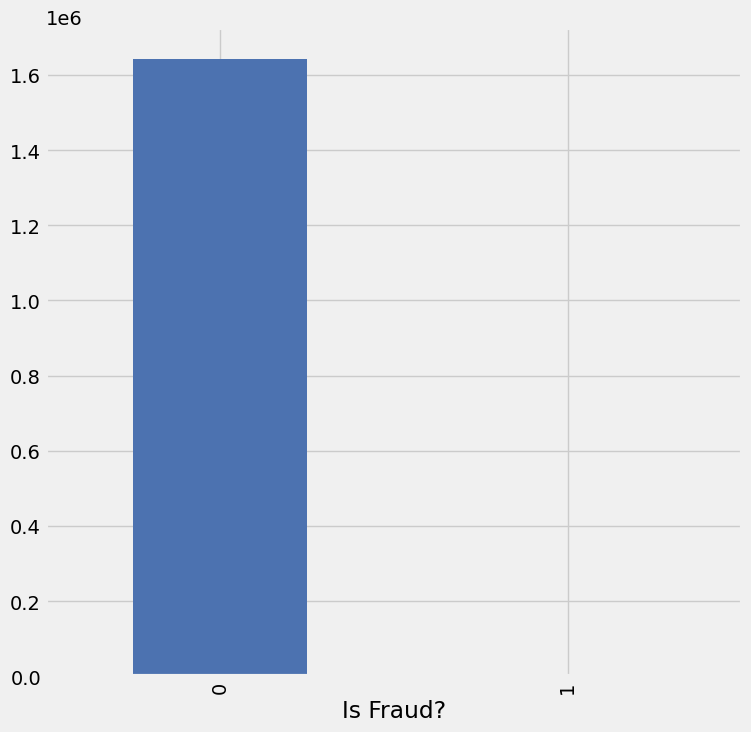

In [ ]:
labels = ['Non Fraud', 'Fraud']
size = data['Is Fraud?'].value_counts()
colors = ['green', 'red']
explode = [0, 0.1]

plt.style.use('seaborn-deep')
plt.rcParams['figure.figsize'] = (8, 8)
plt.pie(size, labels =labels, colors = colors, explode = explode, autopct = "%.2f%%", shadow = True)
plt.axis('off')
plt.title('Target: Fraud or not', fontsize = 20)
plt.legend()
plt.show()
data['Is Fraud?'].value_counts().plot(kind="bar");

- 굉장히 불균형한 데이터를 확인할 수 있다.
- 이는 그만큼 정상 거래 대비 사기 건수가 크지 않다는 것을 의미한다.

#### 2) 각 Feature별 Target Feature 분포

In [22]:
unique_vals = data['Is Fraud?'].unique()
targets = [data.loc[data['Is Fraud?'] == val] for val in unique_vals]
targets

[         Gender  Retirement Age  Birth Year  Birth Month  Zipcode  \
 0             0              66        1966           11   8250.0   
 1             0              66        1966           11   8250.0   
 2             0              66        1966           11   8250.0   
 3             0              66        1966           11   8250.0   
 4             0              66        1966           11   8250.0   
 ...         ...             ...         ...          ...      ...   
 1644763       0              60        1998           11  96946.0   
 1644764       0              60        1998           11  96946.0   
 1644765       0              60        1998           11  96946.0   
 1644766       0              60        1998           11  96946.0   
 1644767       0              60        1998           11  96946.0   
 
          Per Capita Income - Zipcode  Yearly Income    Total Debt  \
 0                           17420410     52077100.0  9.088794e+07   
 1                

/tmp/ipykernel_1586/2181627919.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_1586/2181627919.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_1586/2181627919.py:14: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to

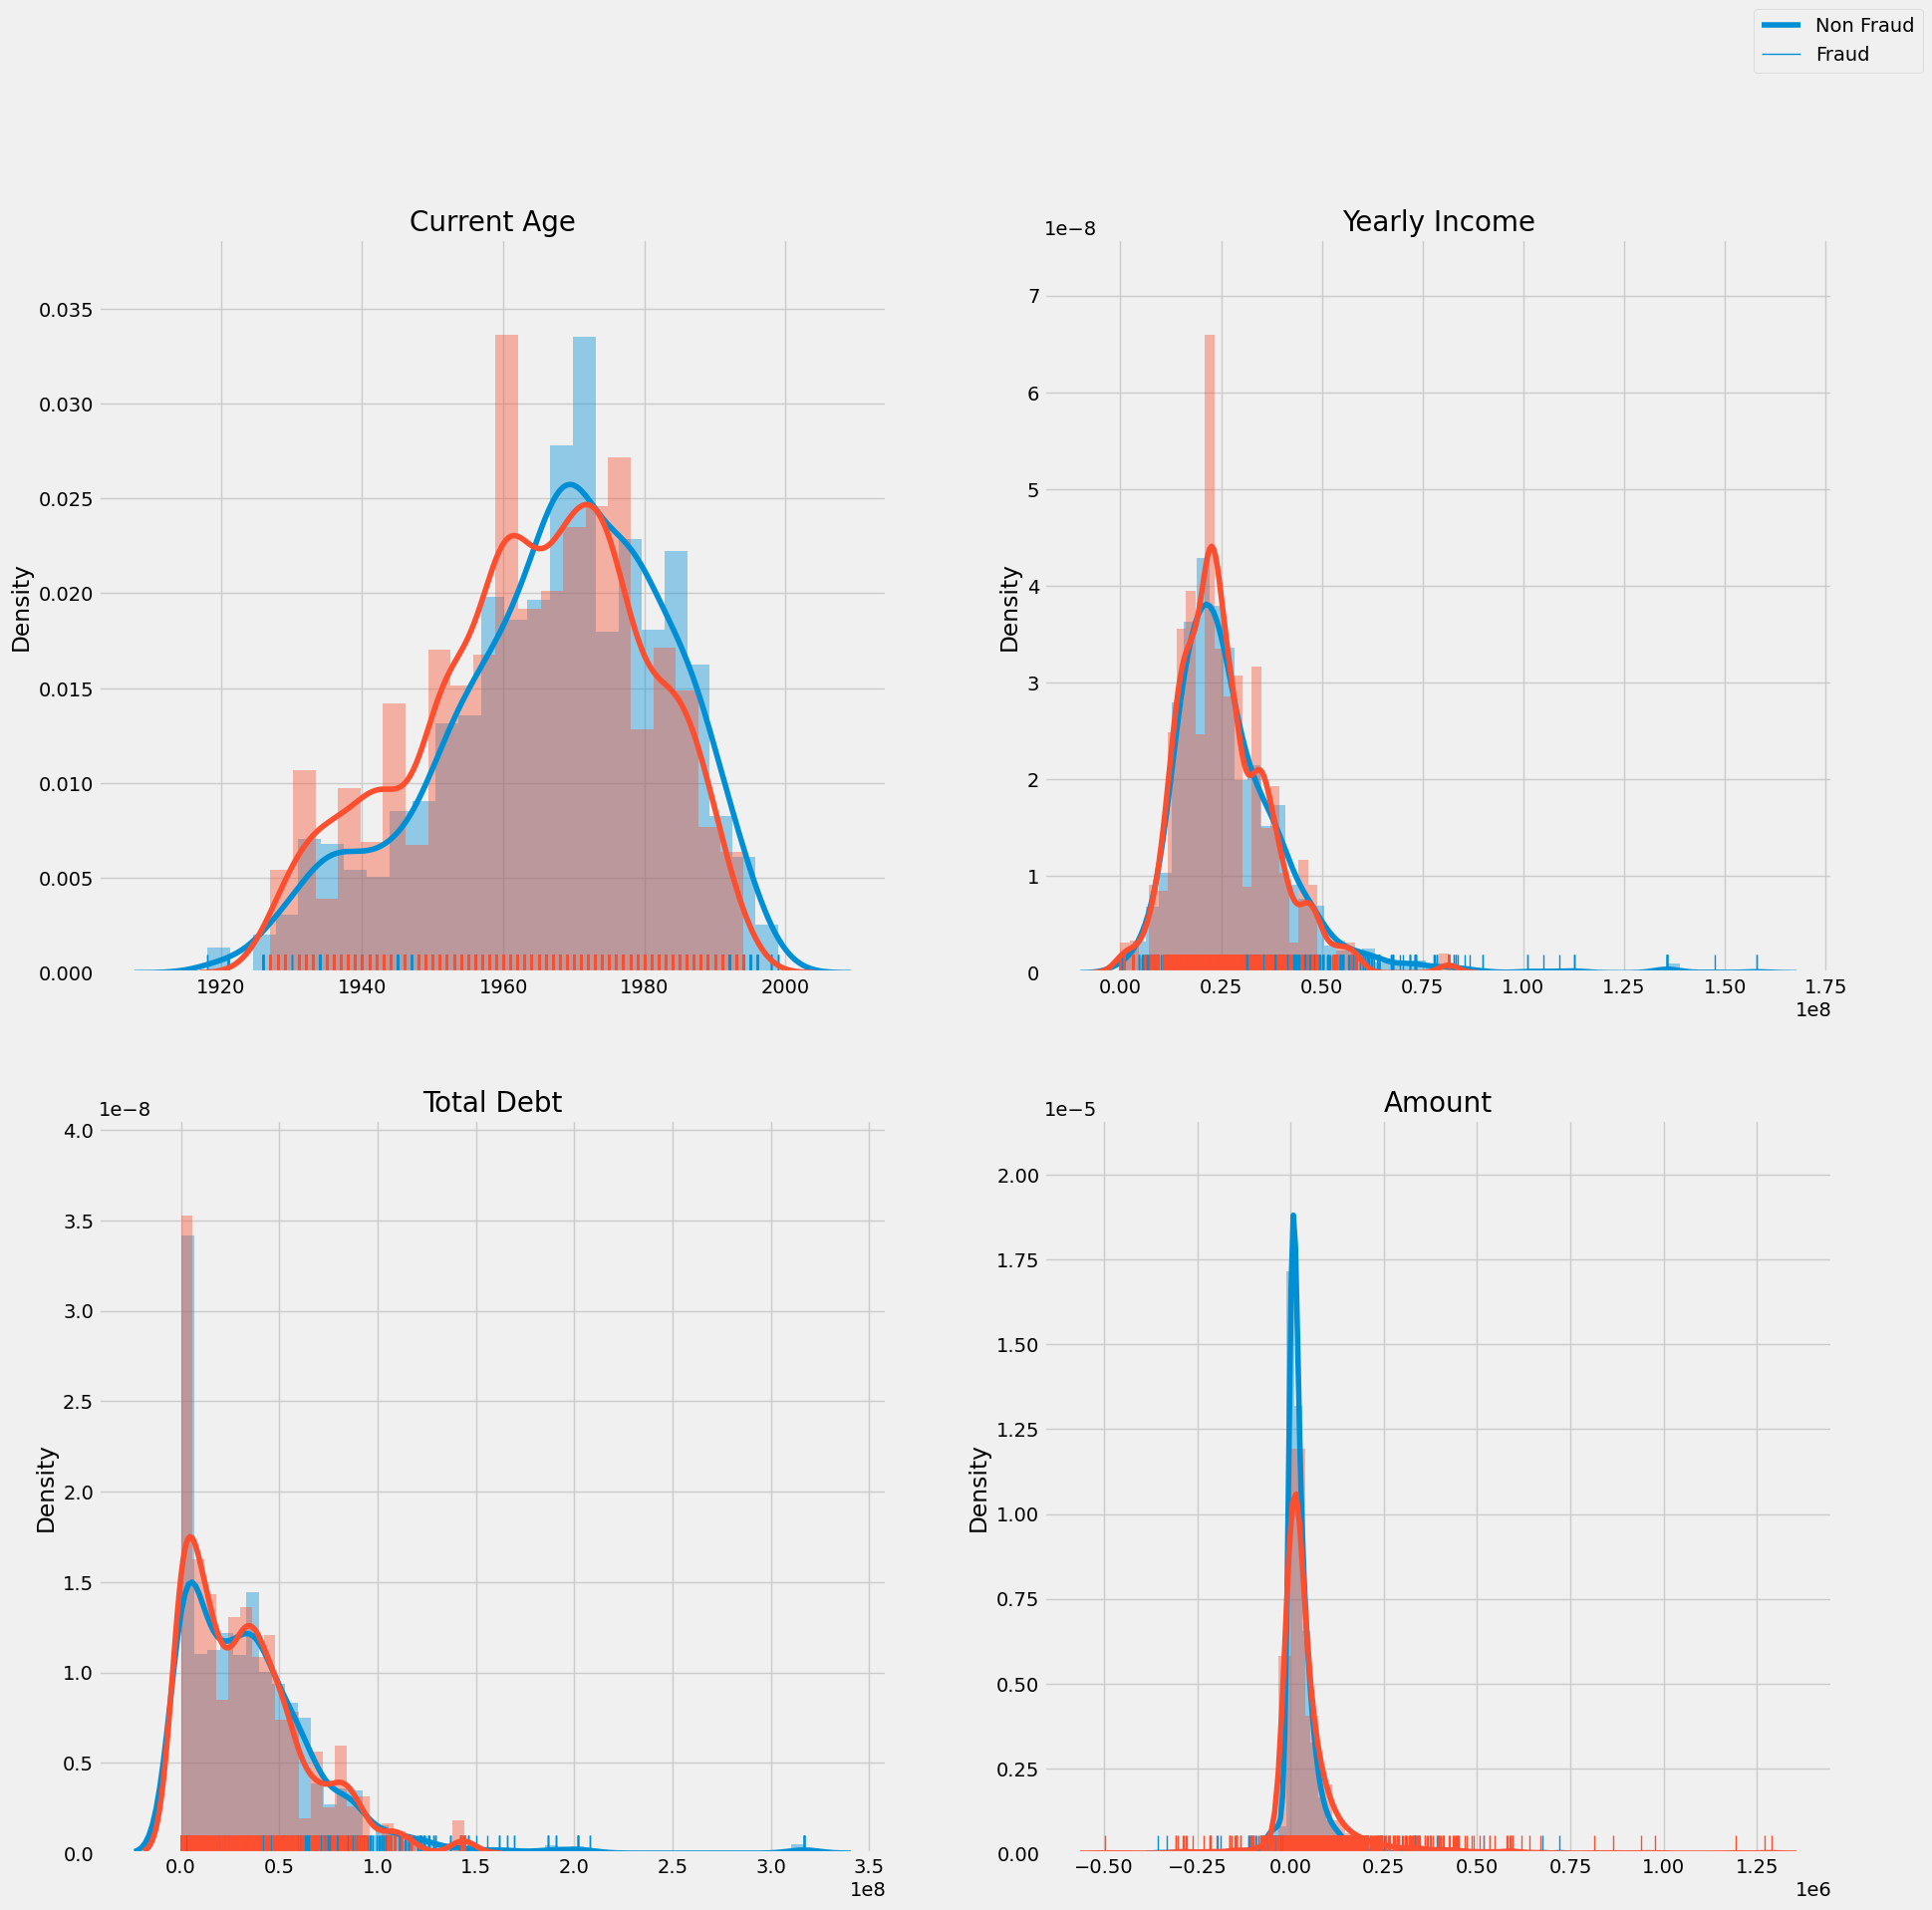

In [23]:
import random

fig = plt.figure(figsize=(20,20))

plt.subplot(2, 2, 1)
for target in targets:
    sampled_data = random.sample(list(target['Birth Year']), 2321)
    sns.distplot(sampled_data, hist=True, rug=True)
plt.title('Current Age', fontsize = 20)

plt.subplot(2, 2, 2)
for target in targets:
    sampled_data = random.sample(list(target['Yearly Income']), 2321)
    sns.distplot(sampled_data, hist=True, rug=True)
plt.title('Yearly Income', fontsize = 20)

plt.subplot(2, 2, 3)
for target in targets:
    sampled_data = random.sample(list(target['Total Debt']), 2321)
    sns.distplot(sampled_data, hist=True, rug=True)
plt.title('Total Debt', fontsize = 20)

plt.subplot(2, 2, 4)
for target in targets:
    sampled_data = random.sample(list(target['Amount']), 2321)
    sns.distplot(sampled_data, hist=True, rug=True)
plt.title('Amount', fontsize = 20)

#sns.add_legend()
#plt.legend()
fig.legend(labels=['Non Fraud','Fraud'])
plt.show()

### 7. 상관성에 따른 Feature 정제

#### 1) 히트맵 확인

Text(0.5, 1.0, 'Corr Heatmap')

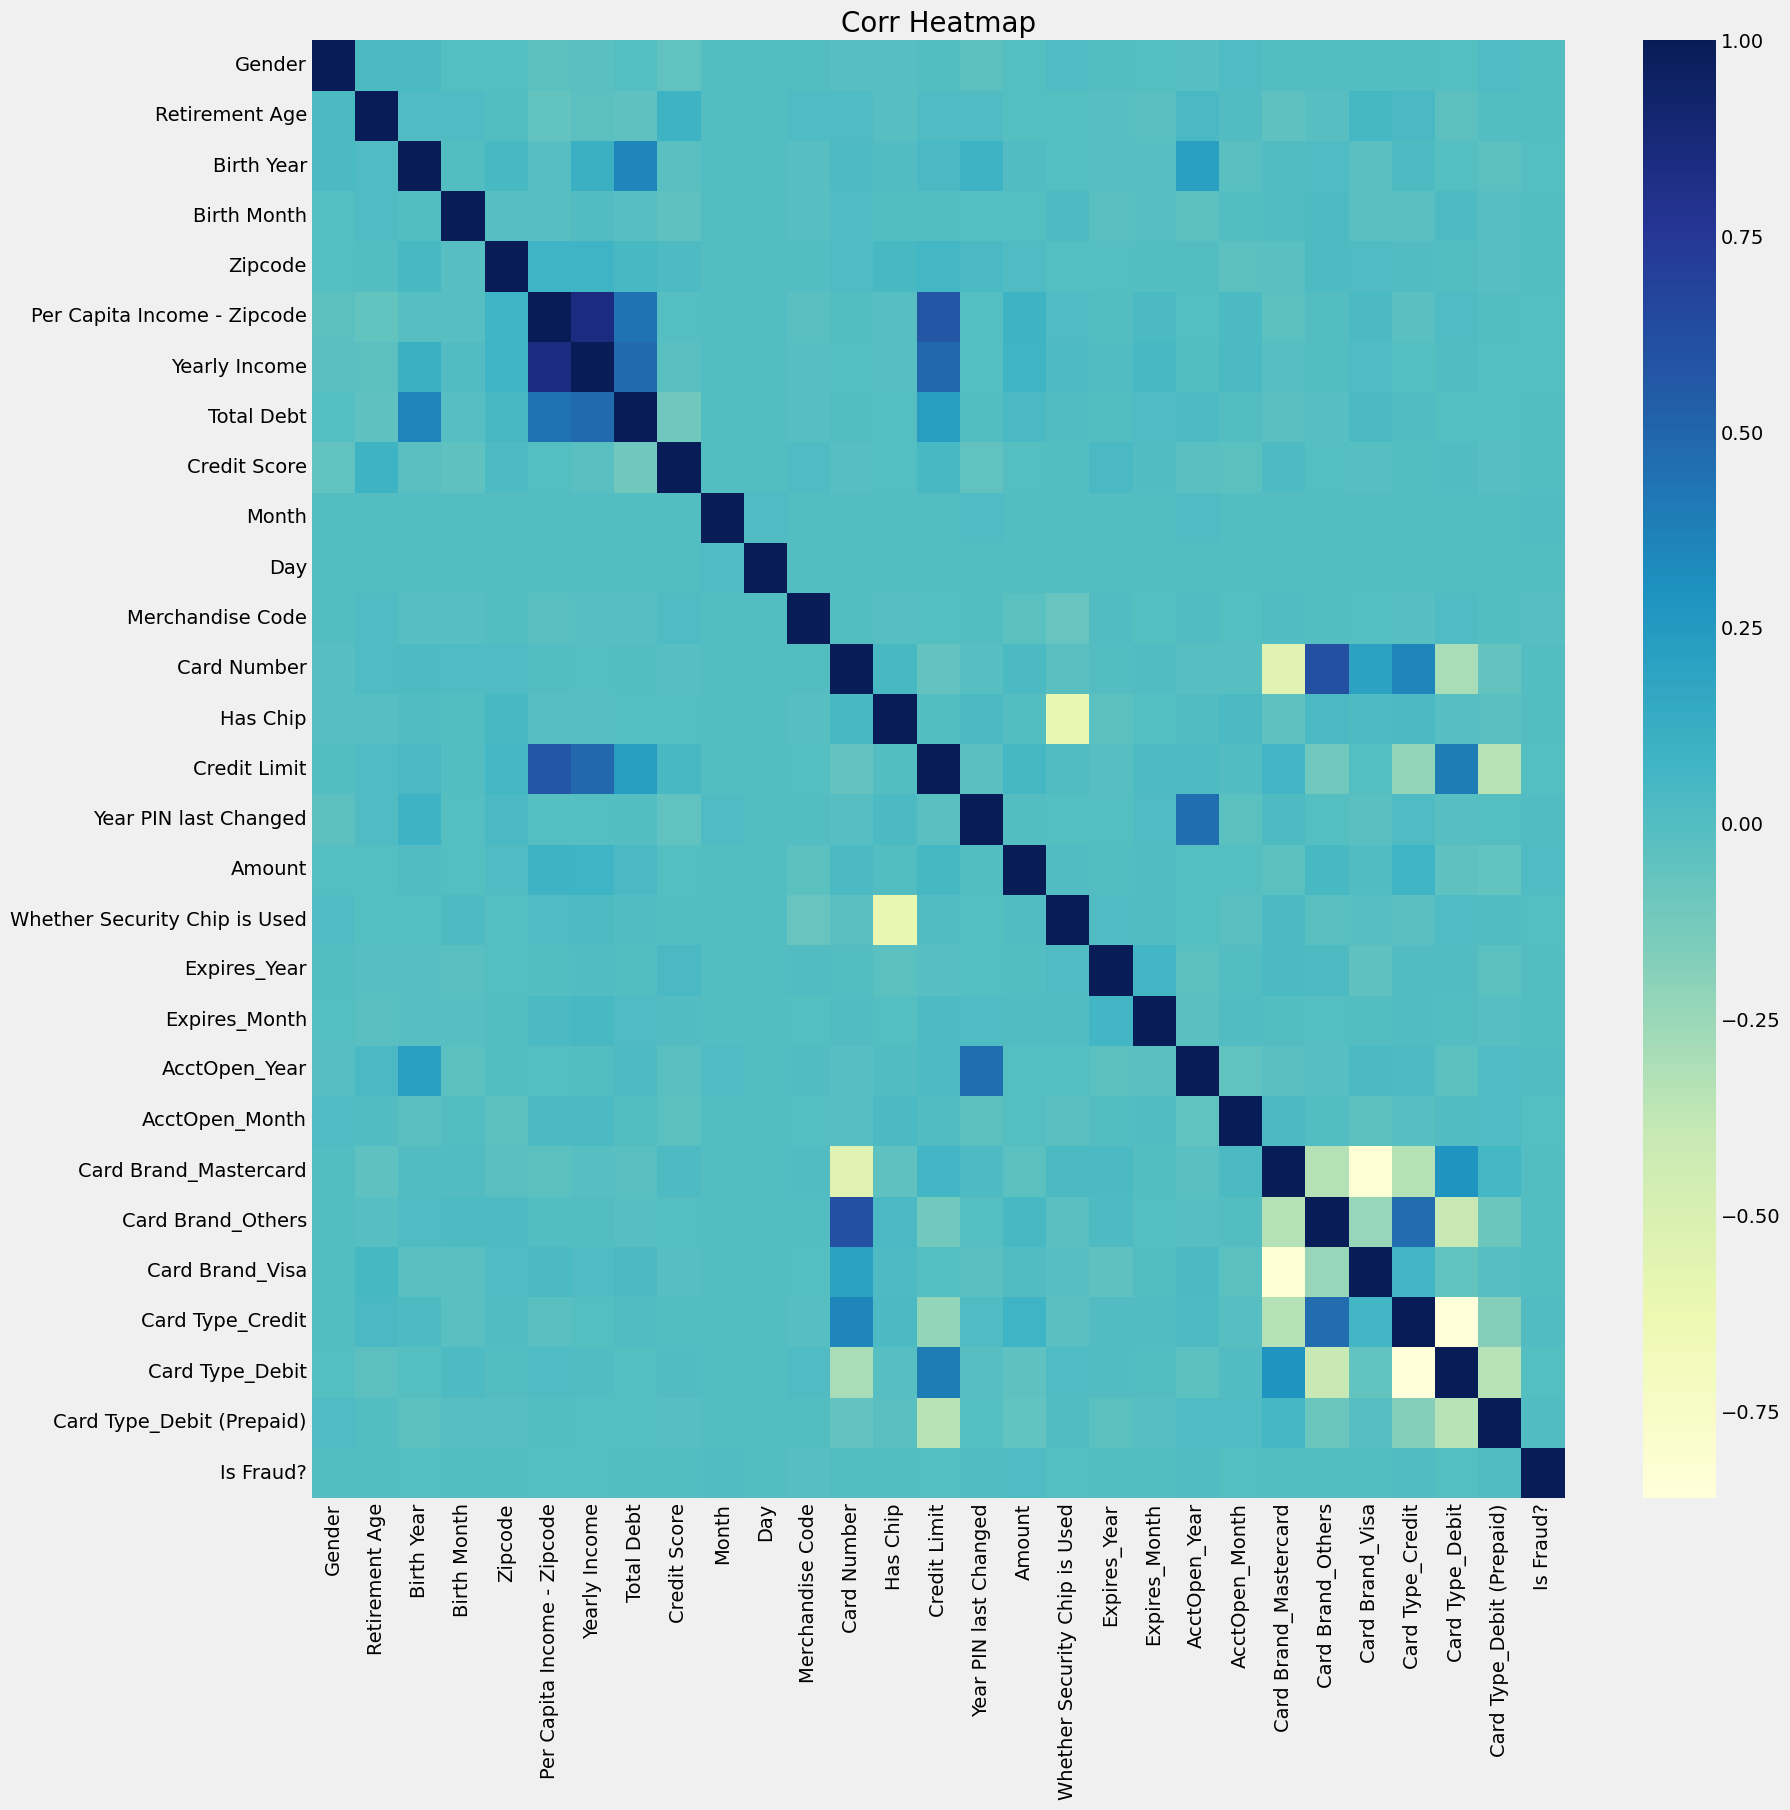

In [ ]:
plt.rcParams['figure.figsize'] = (18, 18)
sns.heatmap(data.corr(), cmap = "YlGnBu")
plt.title('Corr Heatmap', fontsize = 20)

#### 2) 상관계수

##### 상관계수 필터링 함수
> 입력한 상관계수 threshold 에 따라 Feature 들 필터링하는 함수 정의
상관 계수가 높으면 제거한다.

In [ ]:
# 상관계수 구하기
data.corr()

,Gender,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,Credit Score,Month,...,Expires_Month,AcctOpen_Year,AcctOpen_Month,Card Brand_Mastercard,Card Brand_Others,Card Brand_Visa,Card Type_Credit,Card Type_Debit,Card Type_Debit (Prepaid),Is Fraud?
Gender,1.000000,0.027329,0.029667,-0.005752,-0.008269,-0.037499,-0.020087,-0.005899,-0.052333,0.001678,...,-0.007782,-0.012007,0.017985,-0.000176,-0.000560,0.000511,0.000645,-0.009095,0.016415,-0.001504
Retirement Age,0.027329,1.000000,0.011508,0.014983,-0.000835,-0.055458,-0.035586,-0.041343,0.088663,0.001947,...,-0.020854,0.034510,0.007318,-0.042450,-0.011750,0.050664,0.037022,-0.035923,0.001153,0.000257
Birth Year,0.029667,0.011508,1.000000,0.000013,0.046303,-0.013149,0.109098,0.347425,-0.018268,0.003541,...,-0.016316,0.210452,-0.022321,0.010543,0.012190,-0.018051,0.022876,-0.008421,-0.025953,-0.007207
Birth Month,-0.005752,0.014983,0.000013,1.000000,-0.010662,-0.013659,0.004579,-0.015095,-0.046247,0.000065,...,-0.016712,-0.026028,0.003821,0.007344,0.021162,-0.020047,-0.018199,0.024952,-0.014685,0.002408
Zipcode,-0.008269,-0.000835,0.046303,-0.010662,1.000000,0.077288,0.079373,0.046850,0.023360,0.000326,...,0.000885,0.001246,-0.038876,-0.022182,0.019012,0.011640,0.010923,-0.001326,-0.017610,0.000522
Per Capita Income - Zipcode,-0.037499,-0.055458,-0.013149,-0.013659,0.077288,1.000000,0.845217,0.434603,-0.006481,-0.001201,...,0.026061,-0.009547,0.031364,-0.027582,-0.002619,0.029961,-0.020121,0.018453,0.001445,-0.005938
Yearly Income,-0.020087,-0.035586,0.109098,0.004579,0.079373,0.845217,1.000000,0.478249,-0.019966,-0.000454,...,0.044478,0.001440,0.026919,-0.011173,-0.000521,0.011818,-0.008401,0.010148,-0.004126,-0.005501
Total Debt,-0.005899,-0.041343,0.347425,-0.015095,0.046850,0.434603,0.478249,1.000000,-0.101792,0.001341,...,0.017960,0.023100,0.000546,-0.022913,-0.013165,0.031370,0.005998,-0.003707,-0.003903,-0.003129
Credit Score,-0.052333,0.088663,-0.018268,-0.046247,0.023360,-0.006481,-0.019966,-0.101792,1.000000,-0.000968,...,0.005588,-0.018032,-0.032216,0.020642,-0.006130,-0.017650,0.000548,0.005236,-0.011147,0.003002
Month,0.001678,0.001947,0.003541,0.000065,0.000326,-0.001201,-0.000454,0.001341,-0.000968,1.000000,...,0.001189,0.016968,0.001402,-0.003228,0.001373,0.002516,-0.000569,-0.001279,0.003528,0.004825


In [24]:
def remove_collinear_features(x, threshold):
    # 데이터프레임 x 의 상관계수 구하기
    corr_matrix = x.corr()
    # 컬럼수
    iters = range(len(corr_matrix.columns))
    # 제거할 컬럼들 저장할 리스트
    drop_cols = []

    for i in iters:
        for j in range(i+1):

            # j행 (i+1)열 상관계수 가져오기
            item = corr_matrix.iloc[j:(j+1), (i+1):(i+2)]
            # 상관계수 셀의 컬럼명 가져오기
            col = item.columns
            # 상관계수 셀의 행 인덱스 가져오기
            row = item.index
            # 상관계수의 절대값
            val = abs(item.values)

            if val >= threshold:
                print(col.values[0], "열", row.values[0], "행의 상관계수 : ", round(val[0][0], 2))
                drop_cols.append(row.values[0])

    drops = set(drop_cols)

    return drops

In [25]:
threshold = 0.70
drops = remove_collinear_features(data, threshold)
data = data.drop(columns=drops)

Yearly Income 열 Per Capita Income - Zipcode 행의 상관계수 :  0.85
Card Brand_Visa 열 Card Brand_Mastercard 행의 상관계수 :  0.83
Card Type_Debit 열 Card Type_Credit 행의 상관계수 :  0.86


#### 3) 머신러닝 모델 입력 데이터 생성

In [ ]:
data.shape

(1644768, 26)

In [ ]:
data.head()

,Gender,Retirement Age,Birth Year,Birth Month,Zipcode,Yearly Income,Total Debt,Credit Score,Month,Day,...,Whether Security Chip is Used,Expires_Year,Expires_Month,AcctOpen_Year,AcctOpen_Month,Card Brand_Others,Card Brand_Visa,Card Type_Debit,Card Type_Debit (Prepaid),Is Fraud?
0,0,66,1966,11,8250.0,52077100.0,9.088794e+07,779,1,2,...,0,2022,12,2002,9,False,True,True,False,0
1,0,66,1966,11,8250.0,52077100.0,9.088794e+07,779,1,5,...,0,2022,12,2002,9,False,True,True,False,0
2,0,66,1966,11,8250.0,52077100.0,9.088794e+07,779,1,5,...,1,2022,12,2002,9,False,True,True,False,0
3,0,66,1966,11,8250.0,52077100.0,9.088794e+07,779,1,6,...,0,2022,12,2002,9,False,True,True,False,0
4,0,66,1966,11,8250.0,52077100.0,9.088794e+07,779,1,11,...,0,2022,12,2002,9,False,True,True,False,0


### Target Feature 불균형 문제 처리  
- Non Fraud가 Fraud 보다 훨씬 많기 때문에 과적합 문제가 발생할 수 있다.

#### 1. UnderSampling
> 데이터 탐색

In [26]:
# Is Fraud 라벨이 Yes 인 데이터 개수 구하기
fraud_indices = data[data['Is Fraud?'] == 1]
number_fraud_indices = len(fraud_indices)
print(number_fraud_indices)

2321


In [27]:
# Is Fraud 라벨이 No 인 데이터 개수 구하기
non_fraud_indices = data[data['Is Fraud?'] == 0]
number_non_fraud_indices = len(non_fraud_indices)
print(number_non_fraud_indices)

1642447


In [28]:
# Is Fraud 라벨값이 No인 데이터에서 Is Fraud 라벨이 Yes 인 데이터 개수만큼 랜덤으로 가져오기
random_non_fraud_indices = non_fraud_indices.sample(n=number_fraud_indices, replace = False)
print(random_non_fraud_indices.shape)

(2321, 26)


In [29]:
# 같은 비율로 합친 Fraud/Non-Fraud 데이터 생성
under_sample = np.concatenate([fraud_indices.index, random_non_fraud_indices.index])
print(len(under_sample))

4642


In [30]:
undersample_data = data.iloc[under_sample, :]
undersample_data['Is Fraud?'].value_counts()

,count
Is Fraud?,
1,2321
0,2321


In [31]:
x_us = undersample_data.iloc[:, undersample_data.columns != 'Is Fraud?']
y_us = undersample_data.iloc[:, undersample_data.columns == 'Is Fraud?']

print(x_us.shape)
print(y_us.shape)

(4642, 25)
(4642, 1)


In [32]:
# 언더샘플링 데이터 훈련/테스트 데이터 분할
from sklearn.model_selection import train_test_split

x_train_us, x_test_us, y_train_us, y_test_us = train_test_split(x_us, y_us, test_size = 0.1, random_state = 1)

print(x_train_us.shape)
print(y_train_us.shape)
print(x_test_us.shape)
print(y_test_us.shape)

(4177, 25)
(4177, 1)
(465, 25)
(465, 1)


In [33]:
# StandardScaler 적용
# 평균이 1인 피쳐부터 수백만 단위의 피쳐까지 다양하기 때문에
sc = StandardScaler()
x_train_us = sc.fit_transform(x_train_us.astype(float))
x_test_us = sc.transform(x_test_us.astype(float))

#### 2. OverSampling using SMOTE

In [34]:
oversample_data = data.copy()
oversample_data['Is Fraud?'].value_counts()

,count
Is Fraud?,
0,1642447
1,2321


In [35]:
x_os = oversample_data.iloc[:, oversample_data.columns != 'Is Fraud?']
y_os = oversample_data.iloc[:, oversample_data.columns == 'Is Fraud?']

print(x_os.shape)
print(y_os.shape)

(1644768, 25)
(1644768, 1)


In [36]:
# SMOTE 적용
x_os, y_os  = SMOTE(random_state=1).fit_resample(x_os, y_os.values.ravel())

print(x_os.shape)
print(y_os.shape)

(3284894, 25)
(3284894,)


In [37]:
x_train_os, x_test_os, y_train_os, y_test_os = train_test_split(x_os, y_os, test_size = 0.01, random_state = 1)

print(x_train_os.shape)
print(y_train_os.shape)
print(x_test_os.shape)
print(y_test_os.shape)

(3252045, 25)
(3252045,)
(32849, 25)
(32849,)


- 다수 클래스에서 일부를 랜덤으로 언더샘플링하여 데이터의 균형을 맞출 수 있는 방법도 있다

In [38]:
# StandardScaler 적용
sc = StandardScaler()
x_train_os = sc.fit_transform(x_train_os)
x_test_os = sc.transform(x_test_os)

## 03. 머신러닝 모델링

### 1) 데이터 준비

In [39]:
x = data.iloc[:,:(data.shape[1]-1)]
y = data["Is Fraud?"]

print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (1644768, 25)
shape of y: (1644768,)


In [40]:
# 훈련/테스트 데이터 세트 나누기
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1)

print("shape of x_train: ", x_train.shape)
print("shape of x_test: ", x_test.shape)
print("shape of y_train: ", y_train.shape)
print("shape of y_test: ", y_test.shape)

shape of x_train:  (1151337, 25)
shape of x_test:  (493431, 25)
shape of y_train:  (1151337,)
shape of y_test:  (493431,)


### 2) 다양한 Classifier 와 Grid Search 를 활용한 최적 모델 탐색



#### 1. Feature Scailing

In [41]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 선언
sc = StandardScaler()
# StandardScaler 에 fit_transform
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#### 2. XGBoost (Scaled 데이터)

In [ ]:
from sklearn.preprocessing import LabelEncoder

xg = XGBClassifier(random_state=1)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
xg.fit(x_train, y_train)
y_pred = xg.predict(x_test)
y_pred = le.inverse_transform(y_pred)

> Confusion Matrix

Accuracy:  99.88164505270241


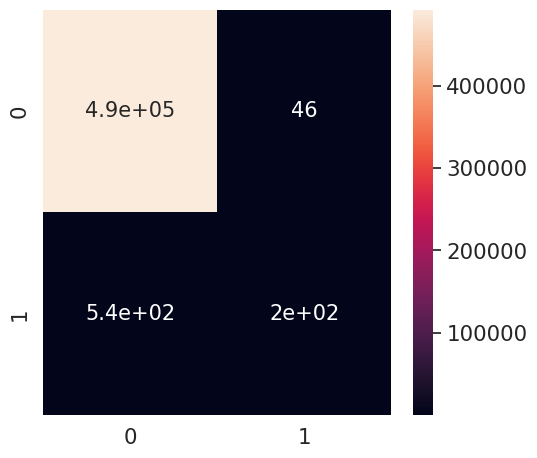

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", xg.score(x_test,y_test)*100)

#### 3. RandomForest (Scaled 데이터)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=1, verbose=0)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

> Confusion Matrix

Accuracy:  99.86786399719514


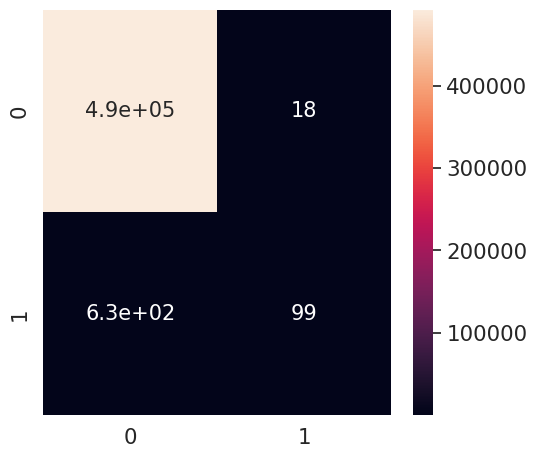

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", rf.score(x_test,y_test)*100)

#### 4. Logistic Regression (Scaled 데이터)

In [ ]:
lr = LogisticRegression(random_state=1)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

> Confusion Matrix

Accuracy:  99.85144832813504


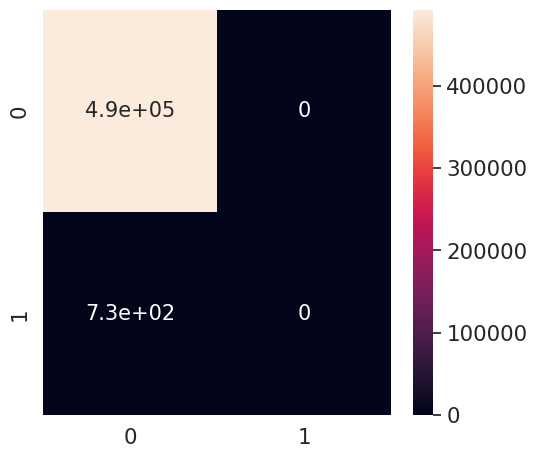

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", lr.score(x_test,y_test)*100)

#### 5. Lasso (Scaled 데이터)

In [ ]:
lasso = Lasso(alpha=0.1,random_state=1)
lasso.fit(x_train,y_train)
y_pred = lasso.predict(x_test)

In [ ]:
# 예측값의 부호를 classifier 로 변환
y_pred2 = np.sign(y_pred)

In [ ]:
print("Accuracy: ", lasso.score(x_test,y_test)*100)

Accuracy:  -0.0007610824161563556


- 모델을 잘 설명하지 못하고 있음

> Confusion Matrix

<Axes: >

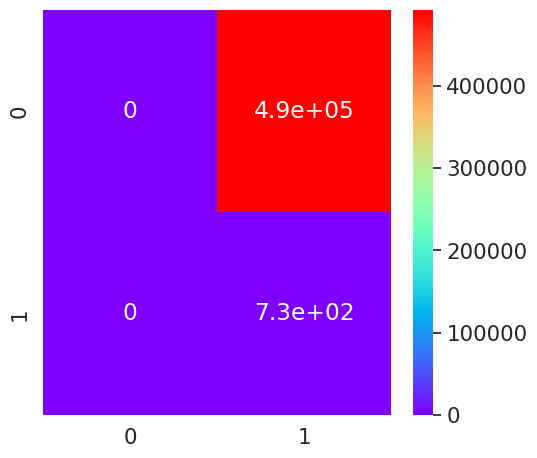

In [ ]:
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

- scaeld data에서 어떤 모델이든 결과가 치우쳐 동일하다
- train 데이터와 y 값의 비율이 같아 과적합이라고 볼 수 있다.

### 3) 언더샘플링 데이터 대상 재모델링

#### 1. XGBoost (Undersampled 데이터)

In [ ]:
model = XGBClassifier(random_state=1)
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)

> Confusion Matrix

Accuracy:  65.54391596798742


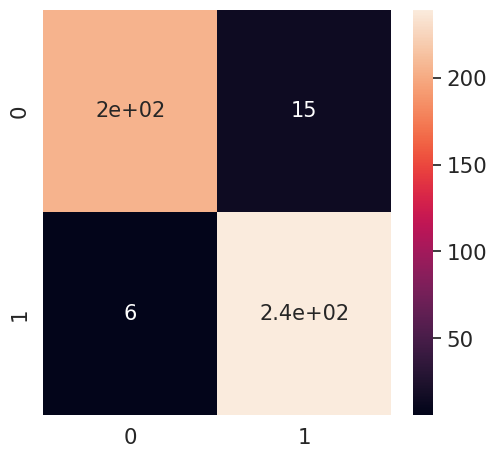

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", model.score(x_test,y_test)*100)

- 비율이 동일하기 때문에 50:50이 정상
- 50보다 나아졌음을 확인

#### 2. Grid Search - XGBoost (Undersampled 데이터)

In [ ]:
parameters = [{'max_depth' : [1, 2, 3, 4, 5, 6],
              'cv' : [2,4,6,8,10],
              'random_state' : [1]}]

grid_search = GridSearchCV(estimator = model, param_grid = parameters, scoring = 'accuracy',  n_jobs = -1)

grid_search = grid_search.fit(x_train_us, y_train_us)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[10:58:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cv" } are not used.




In [ ]:
print("Best Accuracy: ", best_accuracy*100)
print("Best Parameter: ", best_parameters)

Best Accuracy:  94.39824656906283
Best Parameter:  {'cv': 2, 'max_depth': 6, 'random_state': 1}


In [ ]:
# scale_pos_weights 사용
weights = (y == 0).sum()/(1.0*(y == -1).sum())

model = XGBClassifier(max_depth = 3, scale_pos_weights = weights, n_jobs = 4,random_state=1,cv=2)
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)
print("Accuracy: ", model.score(x_test,y_test)*100)

<ipython-input-74-44f484b4ff40>:2: RuntimeWarning:

divide by zero encountered in scalar divide

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[10:58:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cv", "scale_pos_weights" } are not used.




Accuracy:  47.787431272052224


> Confusion Matrix

<Axes: >

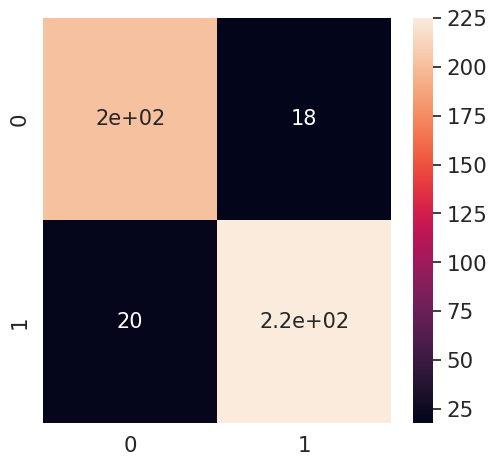

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})

#### 3. Random Forest (Undersampled 데이터)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=1,verbose=0 )
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



> Confusion Matrix

Accuracy:  84.70079909855684


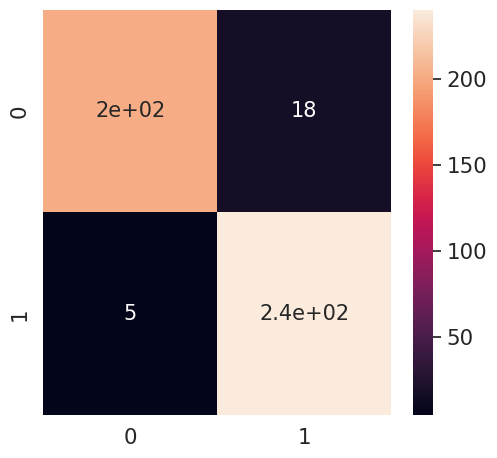

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", model.score(x_test,y_test)*100)

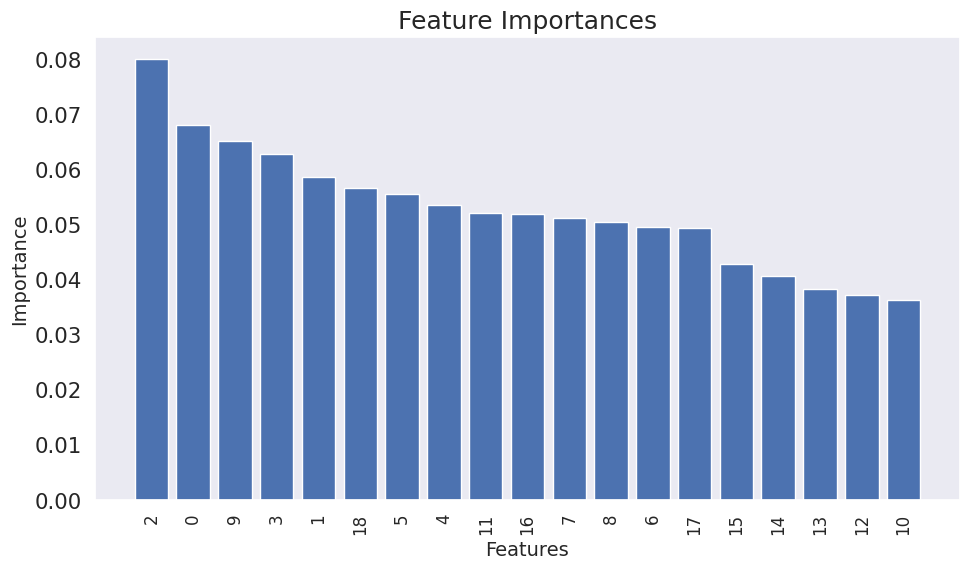

In [ ]:
# 피처 중요도 추출
importances = model.feature_importances_
feature_names = x_train_us.columns

# 피처 중요도를 시각화
indices = np.argsort(importances)[::-1]  # 중요도 순으로 정렬

plt.figure(figsize=(10, 6))
plt.title("Feature Importances", fontsize=18)
plt.bar(range(x_train_us.shape[1]), importances[indices], align="center")
plt.xticks(range(x_train_us.shape[1]), feature_names[indices], rotation=90, fontsize=12)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Importance", fontsize=14)
plt.tight_layout()
plt.show()

#### 4. Logistic Regression (Undersampled 데이터)

In [ ]:
lr = LogisticRegression(random_state=1)
lr.fit(x_train_us, y_train_us)
y_pred = lr.predict(x_test_us)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



> Confusion Matrix

Accuracy:  45.80701253062738


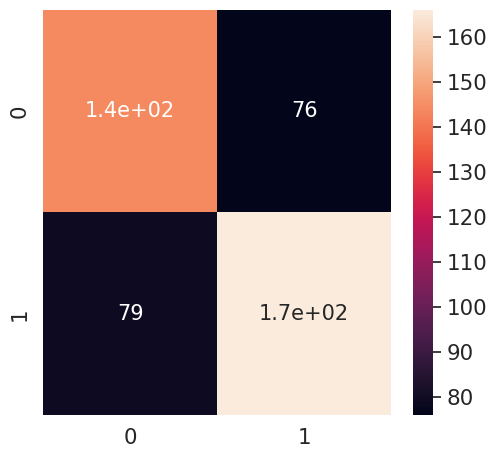

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", lr.score(x_test,y_test)*100)

#### 5. Lasso (Undersampled 데이터)

In [ ]:
lasso = Lasso(alpha=0.1,random_state=1)
lasso.fit(x_train_us,y_train_us)
# print ("Lasso model:", (lasso.coef_))
y_pred = lasso.predict(x_test_us)
print(y_pred)
print(y_test_us)

[0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742
 0.49700742 0.49700742 0.49700742 0.49700742 0.49700742 0.4970

In [ ]:
y_pred2 = np.sign(y_pred)

Accuracy:  -0.3580243645059822


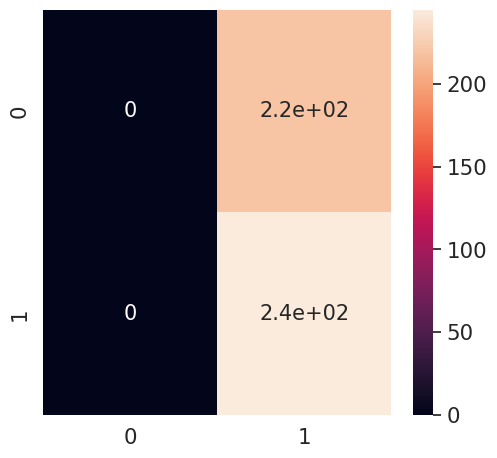

In [ ]:
cm = confusion_matrix(y_test_us, y_pred2)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", lasso.score(x_test_us,y_test_us)*100)

### 4) 오버샘플링 데이터 대상 재모델링
- 데이터가 약 300만개 이상이 되기 때문에 속도가 매우 느립니다.
- 이 부분은 실행하지 말고 코드만 확인해주세요.
- 최종 모델은 오버샘플링과 언더샘플링을 혼합한 모델이 좋을 것 같습니다.

#### 1. XGBoost (Oversampled 데이터)

In [43]:
import xgboost as xgb
from xgboost.sklearn import XGBClassifier

model = XGBClassifier(random_state=1)
model.fit(x_train_os, y_train_os)
y_pred = model.predict(x_test_os)

> Confusion Matrix

Accuracy:  74.35061842486589


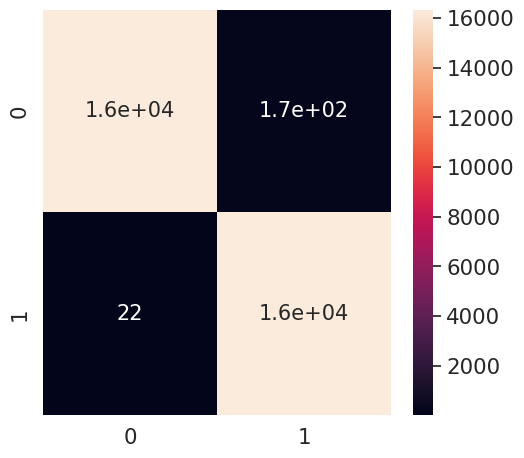

In [44]:
cm = confusion_matrix(y_test_os, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", model.score(x_test,y_test)*100)

#### 2. Grid Search - XGBoost (Oversampled 데이터)

In [45]:
from sklearn.model_selection import GridSearchCV

parameters = [{'max_depth' : [1, 2, 3, 4, 5, 6],
              'cv' : [2,4,6,8,10],
              'random_state' : [1]}]

grid_search = GridSearchCV(estimator = model, param_grid = parameters, scoring = 'accuracy', n_jobs = -1)
grid_search = grid_search.fit(x_train_os, y_train_os)

best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[10:41:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "cv" } are not used.




In [46]:
print("Best Accuracy: ", best_accuracy)
print("Best Parameter: ", best_parameters)

Best Accuracy:  0.993429980212451
Best Parameter:  {'cv': 2, 'max_depth': 6, 'random_state': 1}


In [ ]:
weights = (y == 0).sum()/(1.0*(y == -1).sum())

model = XGBClassifier(max_depth = 1, scale_pos_weights = weights, n_jobs = 4,random_state=1,cv=2)
model.fit(x_train_os, y_train_os)
y_pred = model.predict(x_test_os)

> Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_os, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15}, cmap = 'spring')
print("Accuracy: ", model.score(x_test,y_test)*100)

#### 3. Random Forest (Oversampled 데이터)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=1,verbose=0 )
model.fit(x_train_os, y_train_os)
y_pred = model.predict(x_test_os)
print("Accuracy: ", model.score(x_test_os,y_test_os)*100)

> Confusion Matrix

In [ ]:
# printing the confusion matrix
cm = confusion_matrix(y_test_os, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

#### 4. Logistic Regression (Oversampled 데이터)

In [ ]:
lr = LogisticRegression(random_state=1)
lr.fit(x_train_os, y_train_os)
y_pred = lr.predict(x_test_os)

print("Accuracy: ", lr.score(x_test_os,y_test_os)*100)

> Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_os, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

#### 5. Lasso (Oversampled 데이터)

In [ ]:
lasso = Lasso(alpha=0.1,random_state=1)
lasso.fit(x_train_us,y_train_us)
y_pred = lasso.predict(x_test_us)

In [ ]:
y_pred2 = np.sign(y_pred)

> Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_us, y_pred2)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})

### 5) PCA 를 활용한 차원 축소

In [ ]:
data.shape

(1644768, 26)

#### 1. Scailing using zscore

In [ ]:
from scipy.stats import zscore
data_new=data.iloc[:,:25].apply(zscore)
data_new.head()

,Gender,Retirement Age,Birth Year,Birth Month,Zipcode,Yearly Income,Total Debt,Credit Score,Month,Day,...,Amount,Whether Security Chip is Used,Expires_Year,Expires_Month,AcctOpen_Year,AcctOpen_Month,Card Brand_Others,Card Brand_Visa,Card Type_Debit,Card Type_Debit (Prepaid)
0,-0.9677,-0.103698,-0.055107,1.253086,-1.403744,1.555919,1.604244,0.688323,-1.612863,-1.560623,...,1.085432,-0.605379,0.038255,1.614208,-1.381387,0.730596,-0.313575,1.291353,0.778363,-0.268449
1,-0.9677,-0.103698,-0.055107,1.253086,-1.403744,1.555919,1.604244,0.688323,-1.612863,-1.219660,...,0.856440,-0.605379,0.038255,1.614208,-1.381387,0.730596,-0.313575,1.291353,0.778363,-0.268449
2,-0.9677,-0.103698,-0.055107,1.253086,-1.403744,1.555919,1.604244,0.688323,-1.612863,-1.219660,...,-0.403932,0.698607,0.038255,1.614208,-1.381387,0.730596,-0.313575,1.291353,0.778363,-0.268449
3,-0.9677,-0.103698,-0.055107,1.253086,-1.403744,1.555919,1.604244,0.688323,-1.612863,-1.106005,...,0.576154,-0.605379,0.038255,1.614208,-1.381387,0.730596,-0.313575,1.291353,0.778363,-0.268449
4,-0.9677,-0.103698,-0.055107,1.253086,-1.403744,1.555919,1.604244,0.688323,-1.612863,-0.537734,...,1.451819,-0.605379,0.038255,1.614208,-1.381387,0.730596,-0.313575,1.291353,0.778363,-0.268449


In [ ]:
data_new.isnull().any().any()

False

In [ ]:
data_new = data_new.replace(np.NaN, 0)

In [ ]:
data_new.isnull().any().any()

False

In [ ]:
x = data_new.iloc[:,:25]
y = data["Is Fraud?"]

print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (1644768, 25)
shape of y: (1644768,)


#### 2. PCA Step 1 - Covariance Matrix 만들기

In [ ]:
cov_matrix = np.cov(x.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00000061e+00  2.73291202e-02  2.96672525e-02 -5.75235119e-03
  -8.26917238e-03 -2.00869424e-02 -5.89895712e-03 -5.23330589e-02
   1.67792651e-03 -5.50830361e-04  2.89361825e-03 -1.74602830e-02
  -1.27869812e-02  3.70294924e-05 -3.48149925e-02 -5.28158868e-03
   1.70785553e-02  1.76114978e-03 -7.78158895e-03 -1.20065808e-02
   1.79845809e-02 -5.60397524e-04  5.11414639e-04 -9.09501731e-03
   1.64146774e-02]
 [ 2.73291202e-02  1.00000061e+00  1.15082615e-02  1.49830315e-02
  -8.34783839e-04 -3.55861050e-02 -4.13431074e-02  8.86632932e-02
   1.94733753e-03  1.54860023e-03  1.64984621e-02  1.14588490e-02
  -1.46791935e-02  1.46797256e-02  1.43960264e-02 -4.74777857e-03
  -4.49173360e-03 -1.36975154e-02 -2.08539606e-02  3.45101058e-02
   7.31789885e-03 -1.17495622e-02  5.06636519e-02 -3.59229211e-02
   1.15261102e-03]
 [ 2.96672525e-02  1.15082615e-02  1.00000061e+00  1.29119150e-05
   4.63026294e-02  1.09098192e-01  3.47424934e-01 -1.82678044e-02
   3.54130246e-0

#### 3. PCA Step 2 - Eigen Values 와 Eigen Vector 만들기

In [ ]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-6.58993814e-03 -1.85273912e-02  1.38145143e-02 -3.63656626e-02
   2.73677349e-03 -2.19275525e-02  1.09526680e-02 -2.89584020e-02
  -5.79133202e-03 -6.74851668e-02  9.19991435e-02  2.41756702e-02
   3.05666161e-01 -2.22350513e-01 -2.30333323e-01  2.52471955e-01
  -1.69407413e-01  4.95660946e-01  4.41808963e-02  2.03973600e-01
   1.87411551e-01 -8.92093954e-02 -5.88969748e-01 -1.02690146e-01
   7.00150983e-02]
 [-2.72878223e-02 -2.04014470e-02 -3.28097237e-03  1.28368712e-02
   5.36370460e-02 -4.47433650e-02 -1.79473930e-02 -3.78769210e-02
  -3.14608833e-02 -2.31633683e-02 -9.76993849e-02 -3.58179096e-01
  -5.82010831e-01  1.83948459e-01  5.35990247e-04  4.87314822e-01
  -5.31199436e-02  2.82607253e-01 -5.98929109e-02  9.00183879e-02
  -2.92922751e-01 -9.58866737e-02  5.28712577e-02 -7.35615067e-02
   2.12204593e-01]
 [ 1.39667669e-01  3.12347297e-01 -3.18577932e-02 -6.36087933e-03
   2.88386833e-01 -3.10743869e-02 -9.18577873e-03  4.09983726e-01
  -1.67966528e-01  1

In [ ]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("누적 분산 설명력", cum_var_exp)

누적 분산 설명력 [  8.64070629  16.03279099  22.51933262  28.76863745  34.13012438
  38.84645977  43.33986347  47.62160012  51.78222581  55.86805629
  59.91418801  63.92752639  67.88594181  71.83224975  75.71961228
  79.56311312  83.25028249  86.81160981  90.20906591  92.44227135
  94.45695202  96.27764636  97.79529556  99.09617808 100.        ]


- 90% 까지만 사용하더라도 충분히 설명력 있다.
- eigen value는 설명력을 의미

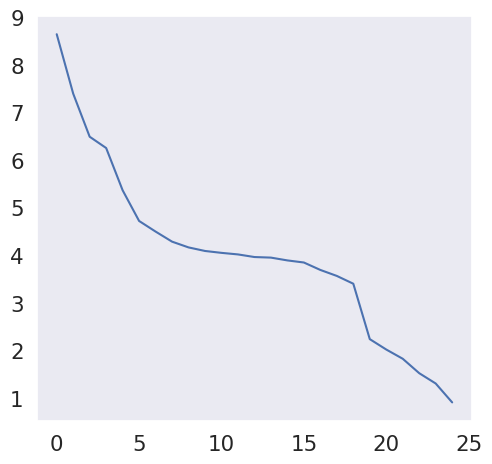

In [ ]:
plt.plot(var_exp)

> Explained Variance Ratio : 각각의 주성분 벡터가 이루는 축에 투영(projection)한 결과의 분산의 비율 (=각 eigenvalue 의 비율)

<ipython-input-103-020cb614a96f>:7: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



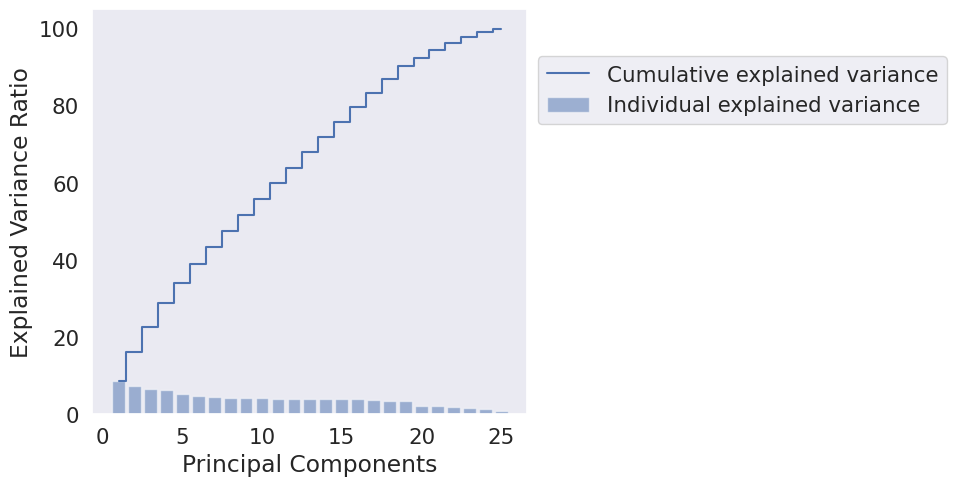

In [ ]:
# Ploting plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.8))
plt.tight_layout()
plt.show()

In [ ]:
len(cum_var_exp)

25

#### 4. Scikit-learn 으로 PCA 적용하기



In [ ]:
# Using scikit learn PCA here. It does all the above steps and maps data to PCA dimensions in one shot
from sklearn.decomposition import PCA

# 90까지의 분산 설명력을 가진 피쳐만 적용
pca = PCA(n_components=19)
data_reduced = pca.fit_transform(x)
data_reduced.transpose()

array([[ 1.69313692,  1.69217598,  1.72025799, ...,  1.00380741,
         0.92607126,  0.95911221],
       [ 0.91041541,  0.89444168,  0.57387136, ...,  2.55016863,
         2.74385574,  2.78929252],
       [-0.04872993, -0.01616093,  0.76573037, ...,  0.0526616 ,
        -0.97997177, -0.69647064],
       ...,
       [-0.45380414, -0.49888552, -0.55575171, ..., -0.83271499,
        -0.69521306, -0.87409573],
       [ 0.8231499 ,  0.69653472,  0.4805057 , ...,  1.34482252,
         1.79005698,  1.2505286 ],
       [ 0.80994943,  0.77552936,  0.77269828, ...,  1.59386722,
         1.71914208,  1.5227592 ]])

In [ ]:
pca.components_

array([[-6.58993814e-03, -2.72878223e-02,  1.39667669e-01,
        -2.39785337e-03,  5.66311589e-02,  3.62102073e-01,
         2.99570862e-01, -8.68485086e-03, -1.52101776e-03,
         4.81970966e-04, -1.13494092e-02, -3.21353908e-01,
        -5.86378788e-02,  4.98084475e-01,  1.92948764e-02,
         3.30960863e-02,  5.75154685e-02, -1.94894487e-03,
         2.92056051e-02,  4.11431687e-02,  8.55850257e-03,
        -3.59954035e-01,  5.01826676e-03,  4.51717623e-01,
        -2.44111511e-01],
       [-1.85273912e-02, -2.04014470e-02,  3.12347297e-01,
        -3.56327352e-04,  1.22658913e-01,  3.85585655e-01,
         4.13491044e-01, -7.89958894e-02,  9.19724870e-03,
         6.28289755e-05, -2.24556219e-02,  4.25525259e-01,
         1.38392449e-01,  1.68175143e-01,  1.23393515e-01,
         1.25610491e-01, -1.16533357e-01, -8.56029965e-03,
         2.48545578e-02,  1.59674736e-01, -1.60586030e-02,
         4.27416322e-01,  2.41412864e-02, -2.71460817e-01,
        -6.04939430e-02],
    

In [ ]:
df_comp = pd.DataFrame(pca.components_,columns=list(x))
df_comp.head()

,Gender,Retirement Age,Birth Year,Birth Month,Zipcode,Yearly Income,Total Debt,Credit Score,Month,Day,...,Amount,Whether Security Chip is Used,Expires_Year,Expires_Month,AcctOpen_Year,AcctOpen_Month,Card Brand_Others,Card Brand_Visa,Card Type_Debit,Card Type_Debit (Prepaid)
0,-0.006590,-0.027288,0.139668,-0.002398,0.056631,0.362102,0.299571,-0.008685,-0.001521,0.000482,...,0.033096,0.057515,-0.001949,0.029206,0.041143,0.008559,-0.359954,0.005018,0.451718,-0.244112
1,-0.018527,-0.020401,0.312347,-0.000356,0.122659,0.385586,0.413491,-0.078996,0.009197,0.000063,...,0.125610,-0.116533,-0.008560,0.024855,0.159675,-0.016059,0.427416,0.024141,-0.271461,-0.060494
2,0.036366,-0.012837,0.006361,0.026615,-0.035682,0.111946,0.101538,-0.007844,-0.006100,-0.002923,...,0.044359,0.669530,0.064313,0.027917,-0.111220,-0.029095,0.116227,-0.045074,-0.116277,0.063681
3,0.002737,0.053637,0.288387,-0.046386,0.004895,-0.095445,0.049659,-0.082162,0.035626,0.001775,...,-0.070663,0.121212,-0.069086,-0.051489,0.586240,-0.095045,-0.210793,0.036751,-0.089812,0.255070
4,0.091999,-0.097699,0.101956,-0.045516,-0.018622,0.231151,0.343757,-0.158832,-0.018095,-0.004997,...,-0.053782,-0.110458,-0.081570,0.001804,-0.267641,0.123237,-0.270069,0.111551,-0.252538,0.563944


<Axes: >

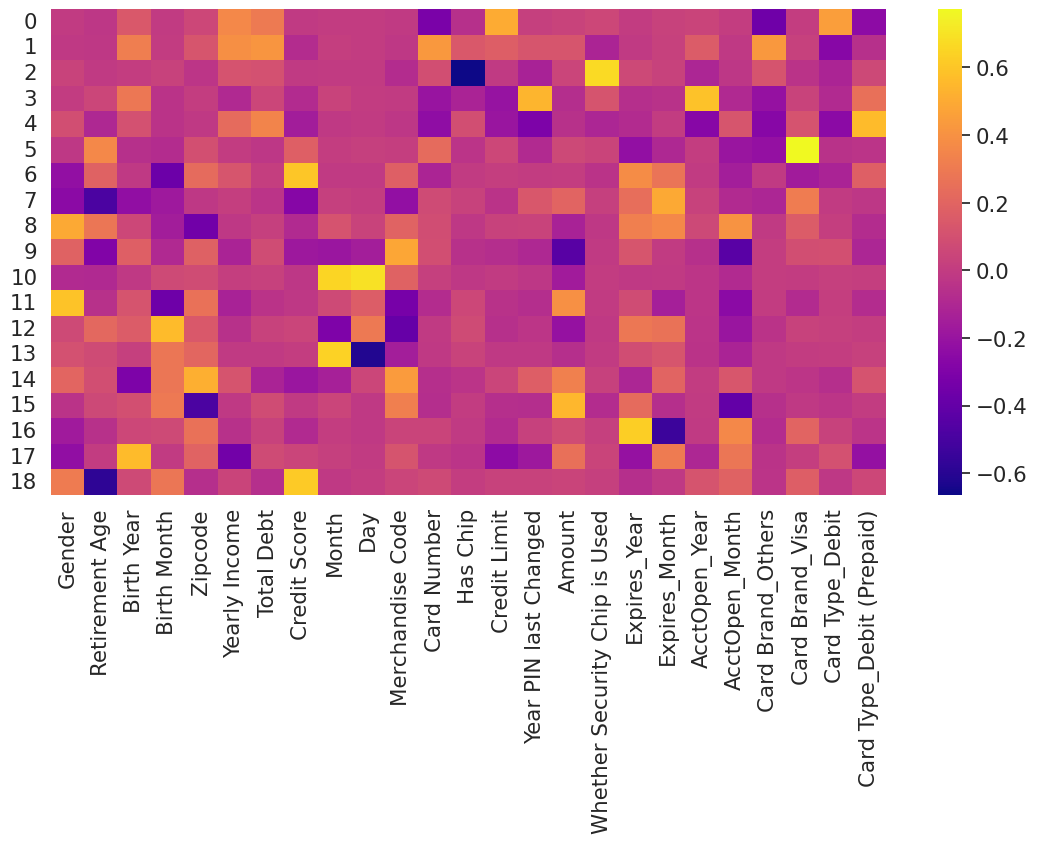

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df_comp,cmap='plasma',)

- 각 주성분 벡터는 단위 벡터로, 벡터의 크기가 1이 되도록 정규화됩니다. 그래서 -1에서 1 사이의 값을 가집니다.
- 값이 1 또는 -1에 가까울수록 해당 특성이 주성분에 크게 기여하고, 0에 가까울수록 기여도가 작다는 것을 의미합니다.


> PCA 적용된 데이터 탐색

In [ ]:
data_reduced.shape

(1644768, 19)

In [ ]:
df_red2 = pd.DataFrame(data_reduced)
df_red2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.693137,0.910415,-0.048730,-2.367635,1.240811,0.792333,0.129374,0.932441,0.485205,-0.376693,-2.119680,-2.151907,0.479600,-0.085777,0.027656,1.503422,-0.453804,0.823150,0.809949
1,1.692176,0.894442,-0.016161,-2.348408,1.266395,0.776215,0.024538,1.017190,0.417878,-0.600978,-1.952975,-1.998370,0.850804,-0.197021,-0.277940,1.188761,-0.498886,0.696535,0.775529
2,1.720258,0.573871,0.765730,-2.103256,1.178071,0.754102,0.039087,0.687755,0.641228,0.160313,-1.659028,-2.651365,0.915023,-0.186567,-0.451951,0.543704,-0.555752,0.480506,0.772698
3,1.682954,0.859242,-0.028926,-2.328400,1.280902,0.760777,0.021328,0.962453,0.458654,-0.494455,-1.828939,-2.089861,0.943827,-0.248921,-0.362819,1.033535,-0.522353,0.624661,0.764997
4,1.710535,0.965957,-0.003089,-2.389902,1.227082,0.824901,0.046851,1.103757,0.392941,-0.893731,-1.553033,-1.699167,0.867625,-0.680970,0.014936,1.551633,-0.456150,0.862195,0.808845


> Is Fraud? 데이터 합치기

In [ ]:
df_red3 = df_red2.copy()
df_red4 = df_red3
df_red4["Is Fraud?"] = data["Is Fraud?"]

In [ ]:
df_red4.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Is Fraud?
0,1.693137,0.910415,-0.048730,-2.367635,1.240811,0.792333,0.129374,0.932441,0.485205,-0.376693,-2.119680,-2.151907,0.479600,-0.085777,0.027656,1.503422,-0.453804,0.823150,0.809949,0
1,1.692176,0.894442,-0.016161,-2.348408,1.266395,0.776215,0.024538,1.017190,0.417878,-0.600978,-1.952975,-1.998370,0.850804,-0.197021,-0.277940,1.188761,-0.498886,0.696535,0.775529,0
2,1.720258,0.573871,0.765730,-2.103256,1.178071,0.754102,0.039087,0.687755,0.641228,0.160313,-1.659028,-2.651365,0.915023,-0.186567,-0.451951,0.543704,-0.555752,0.480506,0.772698,0
3,1.682954,0.859242,-0.028926,-2.328400,1.280902,0.760777,0.021328,0.962453,0.458654,-0.494455,-1.828939,-2.089861,0.943827,-0.248921,-0.362819,1.033535,-0.522353,0.624661,0.764997,0
4,1.710535,0.965957,-0.003089,-2.389902,1.227082,0.824901,0.046851,1.103757,0.392941,-0.893731,-1.553033,-1.699167,0.867625,-0.680970,0.014936,1.551633,-0.456150,0.862195,0.808845,0


#### 5. 이상치 제거

> Is Fraud? 별 PCA 데이터의 이상치 탐색

array([[<Axes: title={'center': '0'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '1'}, xlabel='Is Fraud?'>],
       [<Axes: title={'center': '2'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '3'}, xlabel='Is Fraud?'>],
       [<Axes: title={'center': '4'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '5'}, xlabel='Is Fraud?'>]], dtype=object)

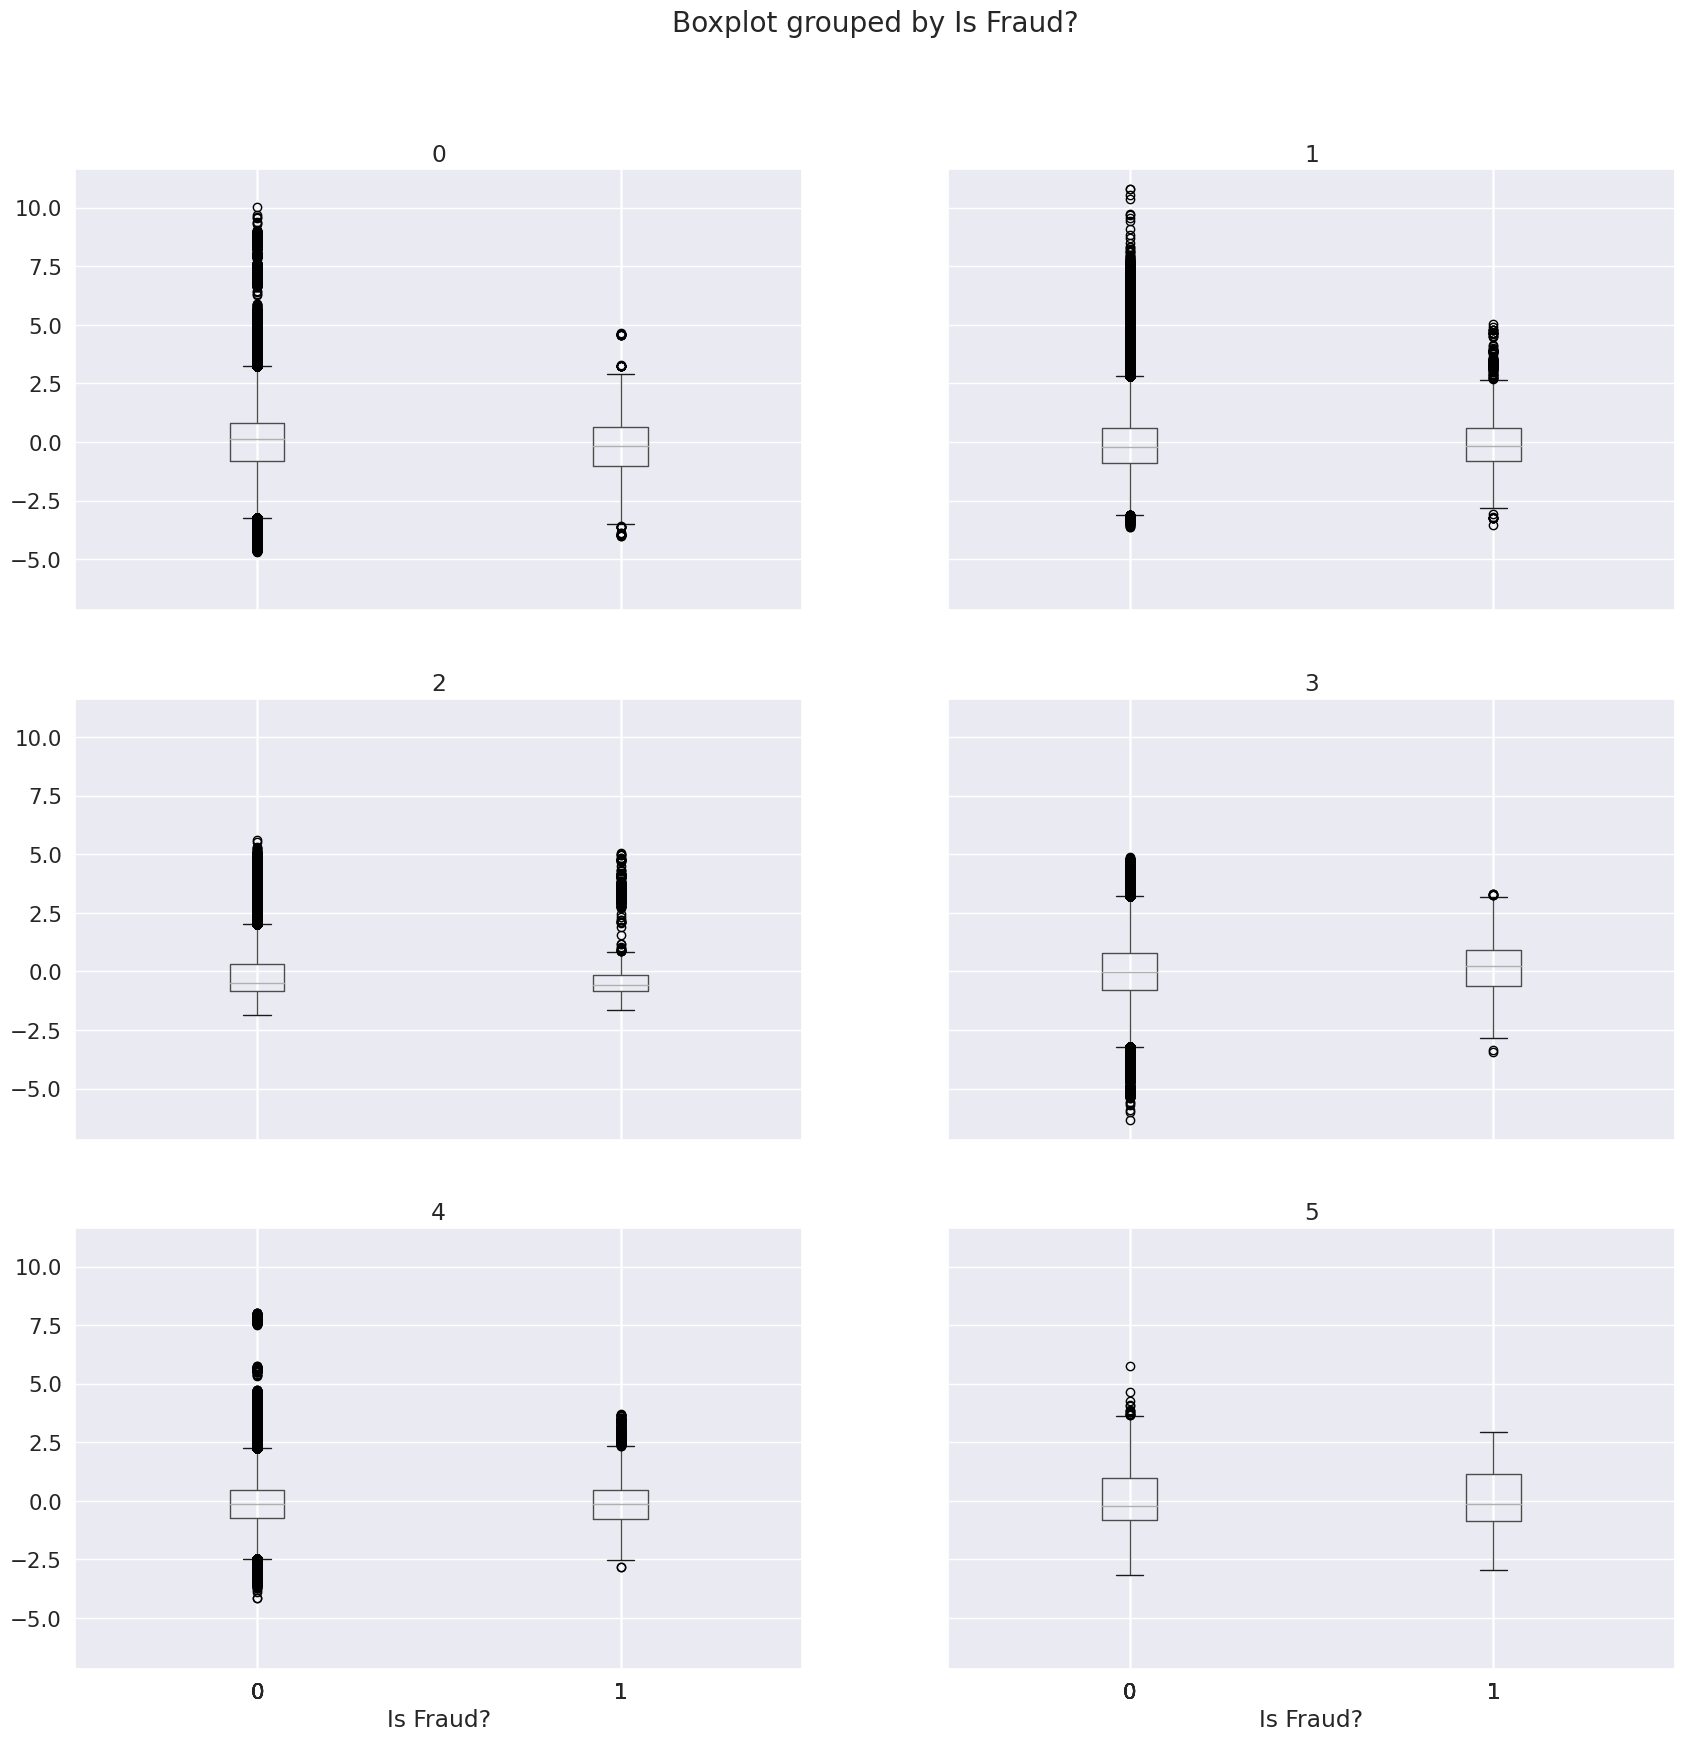

In [ ]:
df_red4.boxplot(column = [df_red4.columns[0],
                          df_red4.columns[1],
                          df_red4.columns[2],
                          df_red4.columns[3],
                          df_red4.columns[4],
                          df_red4.columns[5],
                         ]
                          , by = 'Is Fraud?', figsize=(20,20))

> 이상치 제거 적용 (Quantile, IQR 사용)

In [ ]:
pd_data = df_red4.copy()

from scipy import stats

def outlier_removal_max(var):
    var = np.where(var > var.quantile(0.75)+ stats.iqr(var),var.quantile(0.50),var)
    return var

def outlier_removal_min(var):
    var = np.where(var < var.quantile(0.25) - stats.iqr(var),var.quantile(0.50),var)
    return var

for column in pd_data:
    pd_data[column] = outlier_removal_max(pd_data[column])
    pd_data[column] = outlier_removal_min(pd_data[column])

array([[<Axes: title={'center': '0'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '1'}, xlabel='Is Fraud?'>],
       [<Axes: title={'center': '2'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '3'}, xlabel='Is Fraud?'>],
       [<Axes: title={'center': '4'}, xlabel='Is Fraud?'>,
        <Axes: title={'center': '5'}, xlabel='Is Fraud?'>]], dtype=object)

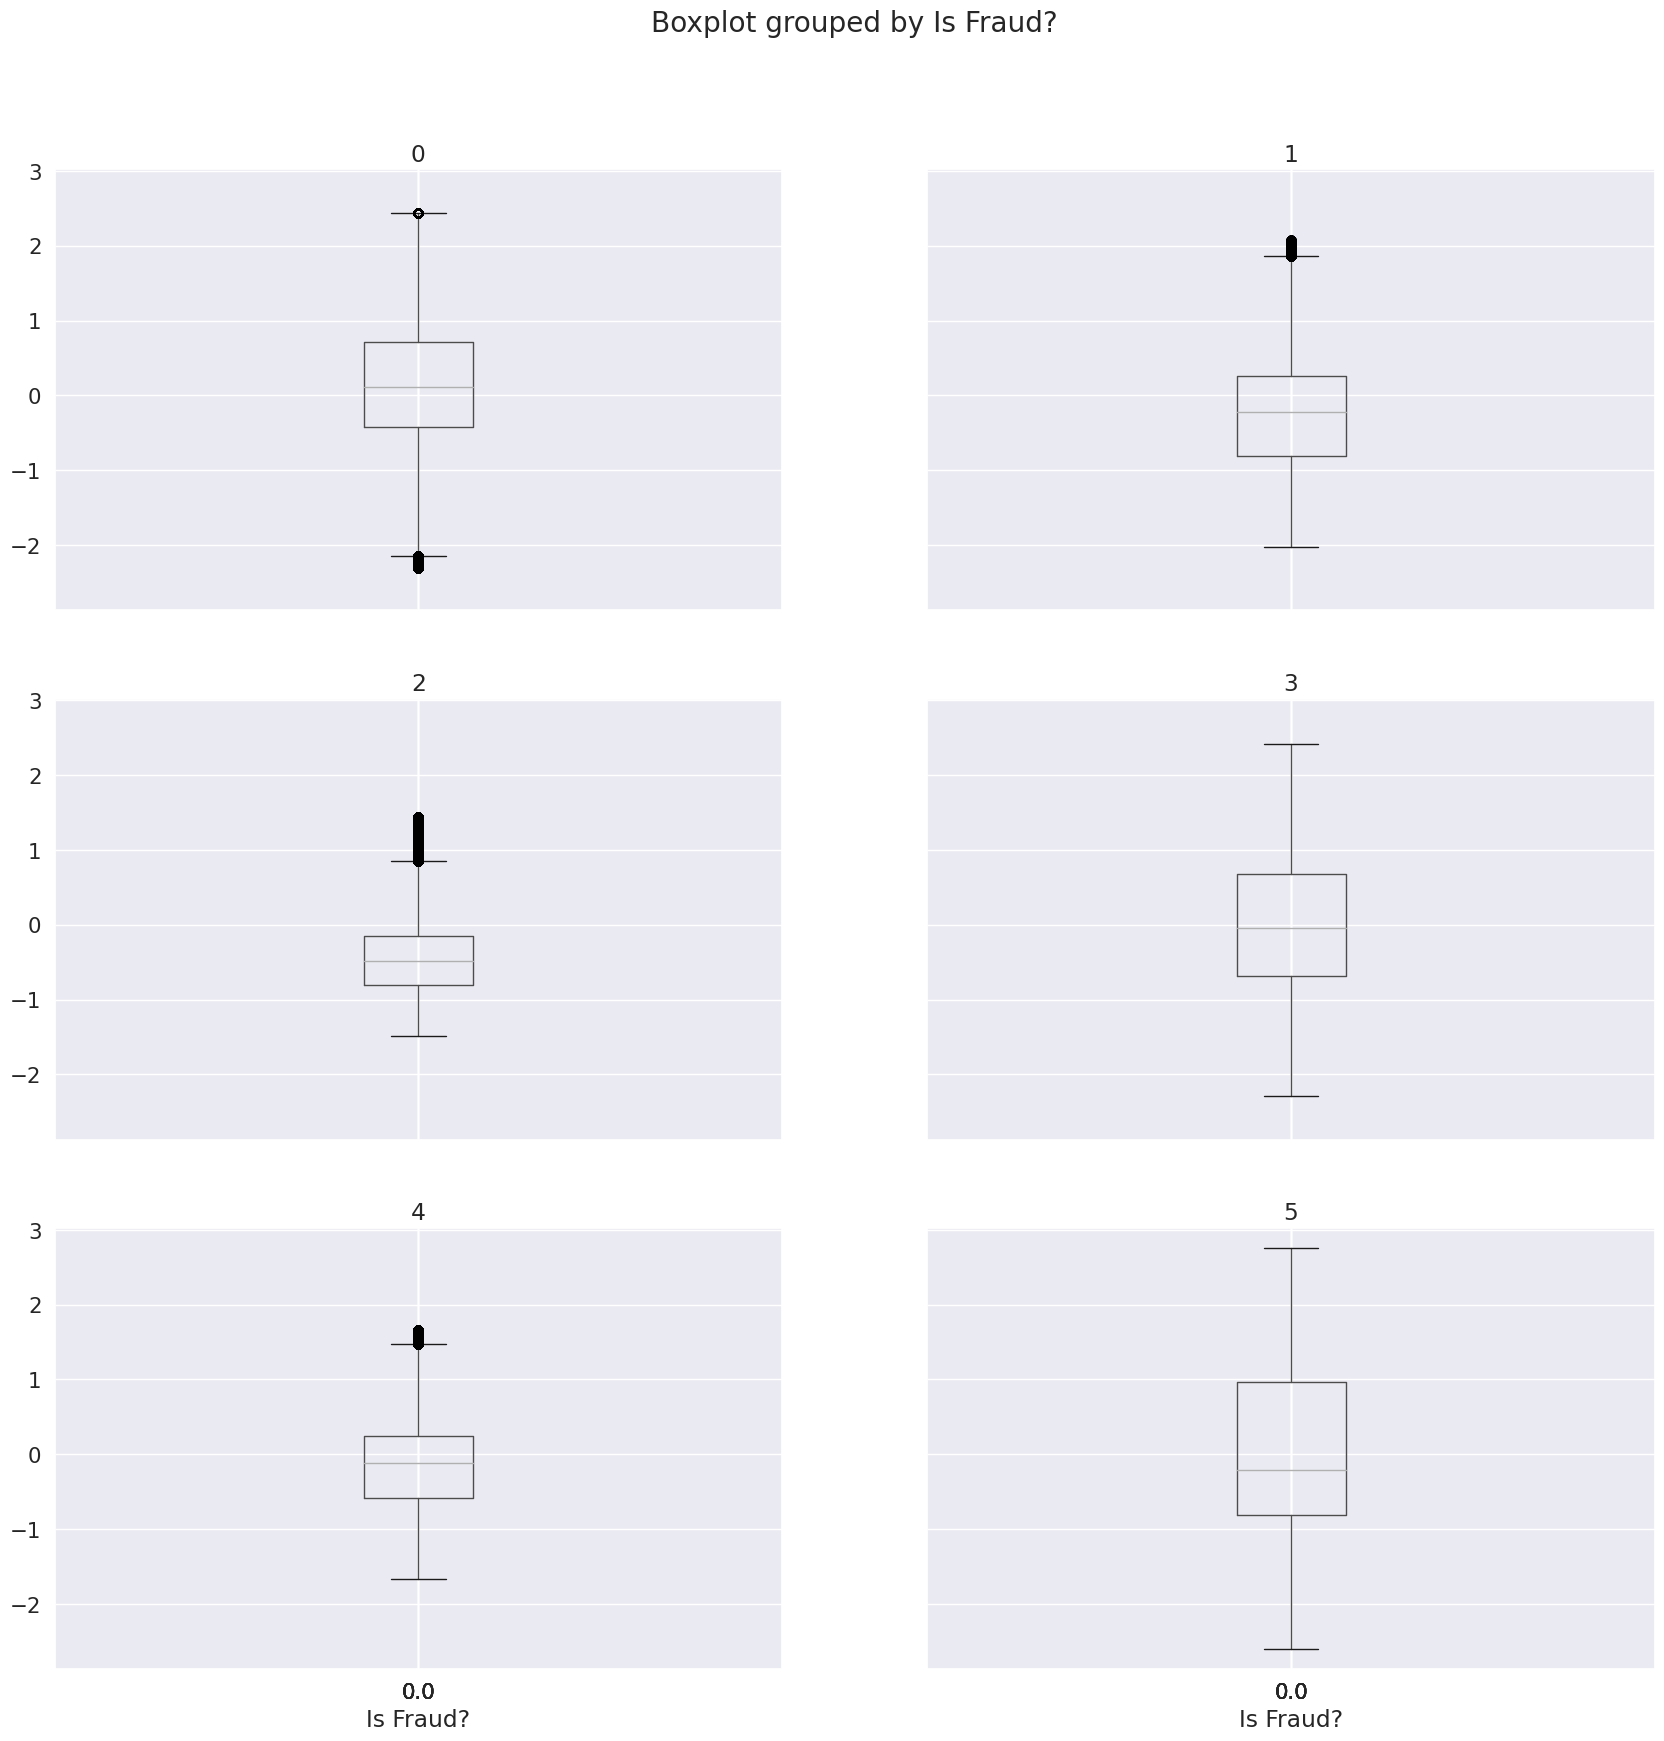

In [ ]:
pd_data.boxplot( column =[df_red4.columns[0],
                          df_red4.columns[1],
                          df_red4.columns[2],
                          df_red4.columns[3],
                          df_red4.columns[4],
                          df_red4.columns[5],
                         ],by = 'Is Fraud?', figsize=(20,20))

### 6) PCA 적용+이상치 제거 데이터 재모델링

#### 1. 언더샘플링


In [ ]:
x = df_red4.iloc[:, df_red4.columns != 'Is Fraud?']
y = df_red4.iloc[:, df_red4.columns == 'Is Fraud?']

print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (1644768, 19)
shape of y: (1644768, 1)


In [ ]:
fraud_indices = np.array(df_red4[df_red4['Is Fraud?'] == 1].index)
number_fraud_indices = len(fraud_indices)

print(number_fraud_indices)

2321


In [ ]:
non_fraud_indices = df_red4[df_red4['Is Fraud?'] == 0]
number_non_fraud_indices = len(non_fraud_indices)

print(number_non_fraud_indices)

1642447


In [ ]:
random_normal_indices = np.random.choice(number_non_fraud_indices, size=number_fraud_indices, replace = True)
random_normal_indices = np.array(random_normal_indices)

print(len(random_normal_indices))

2321


In [ ]:
under_sample = np.concatenate([fraud_indices, random_normal_indices])
print(len(under_sample))

4642


In [ ]:
undersample_data = df_red4.iloc[under_sample, :]

x = undersample_data.iloc[:, undersample_data.columns != 'Is Fraud?']
y = undersample_data.iloc[:, undersample_data.columns == 'Is Fraud?']

print(x.shape)
print(y.shape)

(4642, 19)
(4642, 1)


In [ ]:
from sklearn.model_selection import train_test_split

x_train_us, x_test_us, y_train_us, y_test_us = train_test_split(x, y, test_size = 0.1, random_state = 1)

print(x_train_us.shape)
print(y_train_us.shape)
print(x_test_us.shape)
print(y_test_us.shape)

(4177, 19)
(4177, 1)
(465, 19)
(465, 1)


#### 1. XGBoost-PCA (Undersampled 데이터)

In [ ]:
model = XGBClassifier(random_state=1)
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)

> Confusion Matrix

Accuracy:  92.90322580645162


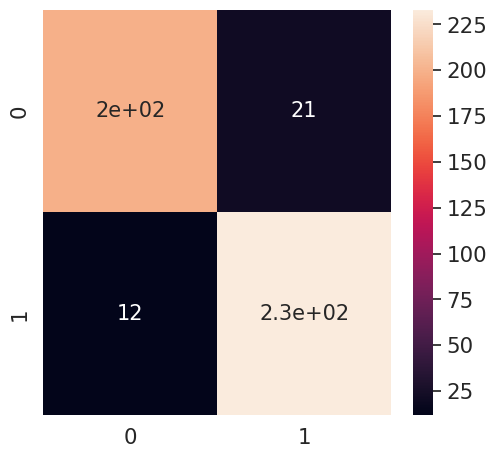

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", model.score(x_test_us,y_test_us)*100)

#### 2. Grid Search - XGBoost - PCA (Undersampled 데이터)

In [ ]:
parameters = [{'max_depth' : [1, 2, 3, 4, 5, 6],
              'cv' : [2,4,6,8,10],
             'random_state' : [1]}]

grid_search = GridSearchCV(estimator = model, param_grid = parameters, scoring = 'accuracy', n_jobs = -1)

grid_search = grid_search.fit(x_train_us, y_train_us)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print("Best Accuracy: ", best_accuracy*100)
print("Best Parameter: ", best_parameters)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[11:25:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cv" } are not used.




Best Accuracy:  89.1308483511446
Best Parameter:  {'cv': 2, 'max_depth': 6, 'random_state': 1}


In [ ]:
weights = (y == 0).sum()/(1.0*(y == -1).sum())

model = XGBClassifier(max_depth = 4, scale_pos_weights = weights, n_jobs = 4,random_state=1,cv=2)
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)

print("Accuracy: ", model.score(x_test_us,y_test_us)*100)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[11:25:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cv", "scale_pos_weights" } are not used.




Accuracy:  88.6021505376344


> Confusion Matrix

<Axes: >

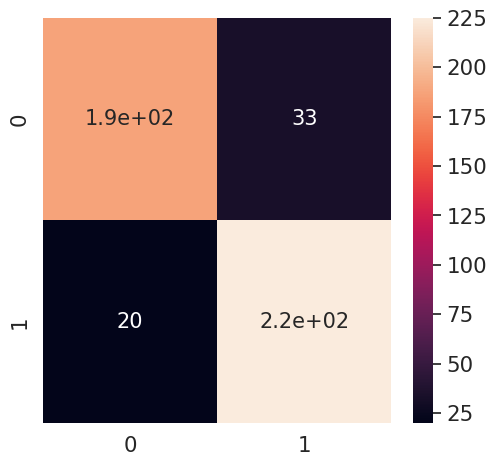

In [ ]:
cm = confusion_matrix(y_test_us, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})

#### 3. Random Forest - PCA (Undersampled 데이터)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



Accuracy:  93.33333333333333


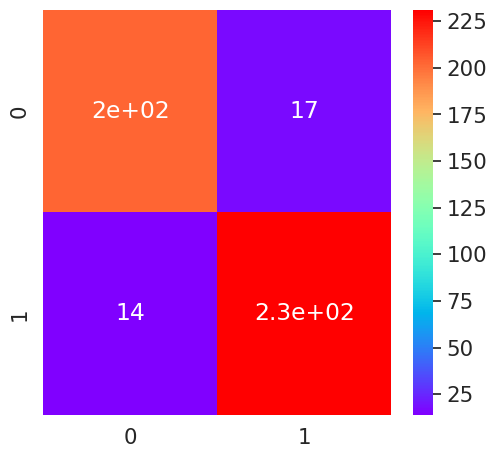

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=1,verbose=0 )
model.fit(x_train_us, y_train_us)
y_pred = model.predict(x_test_us)

cm = confusion_matrix(y_test_us, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')
print("Accuracy: ", model.score(x_test_us,y_test_us)*100)

#### 4. Logistic Regression - PCA (Undersampled 데이터)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Accuracy:  59.56989247311828


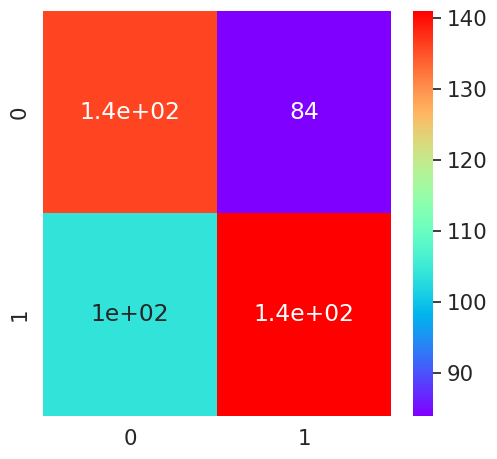

In [ ]:
lr = LogisticRegression(random_state=1)
lr.fit(x_train_us, y_train_us)
y_pred = lr.predict(x_test_us)

cm = confusion_matrix(y_test_us, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')
print("Accuracy: ", lr.score(x_test_us,y_test_us)*100)

#### 5. Lasso - PCA (Undersampled 데이터)

In [ ]:
lasso = Lasso(alpha=0.1,random_state=1)
lasso.fit(x_train_us,y_train_us)

y_pred = lasso.predict(x_test_us)

y_pred2 = np.sign(y_pred)

In [ ]:
actual_cost = list(y_test_us)
actual_cost = np.asarray(actual_cost)
y_pred_lass = lasso.predict(x_test_us)
print("Accuracy: ", lasso.score(x_test_us, y_test_us)*100)

Accuracy:  0.38876764337969494


> Confusion Matrix

<Axes: >

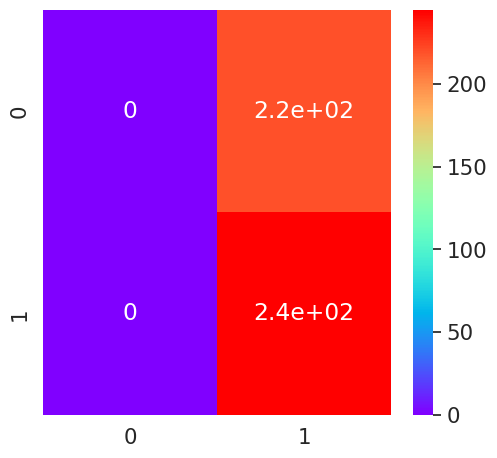

In [ ]:
cm = confusion_matrix(y_test_us, y_pred2)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

- Oversampling + Undersampling을 조합하여 약 800만개의 데이터만 사용하여 시도해보기.
- 80만이 많다면 더 줄여도 됨.
- 현재 언더샘플링 + PCA + 이상치 제거 RandomForest 방식이 93.3%로 제일 높다.
- 이 이상이 나올 수 있도록 시도해보기.

#### 2. 언더샘플링 + 오버샘플링
- train 데이터를 80만 개로 줄인 후(언더샘플링)
- 사기인 데이터를 80만 개로 증가(오버샘플링)

In [47]:
from sklearn.model_selection import train_test_split
#UnderSampling
#Fraud==1
fraud_indices=data[data['Is Fraud?'] == 1]
number_fraud_indices = len(fraud_indices)
#Fraud==0
non_fraud_indices=data[data['Is Fraud?'] == 0]
number_non_fraud_indices = len(non_fraud_indices)
#Undersampling(Fraud==0인 경우)
under_val = non_fraud_indices.sample(n=800000, replace=False)

In [48]:
#Oversampling(Fraud==1인 경우)
#1:1비율(각 800000)로 만들기 위해 under_val(undersampling data)와 fraud data combine
x_fraud = fraud_indices.drop(columns=['Is Fraud?'])
y_fraud = fraud_indices['Is Fraud?']
x_non_fraud = under_val.drop(columns=['Is Fraud?'])
y_non_fraud = under_val['Is Fraud?']
x_combined = pd.concat([x_fraud, x_non_fraud], axis=0)
y_combined = pd.concat([y_fraud, y_non_fraud], axis=0)

smote = SMOTE(sampling_strategy=1.0, random_state=1)
x_os, y_os = smote.fit_resample(x_combined, y_combined)
print(x_os.shape)

(1600000, 25)


In [49]:
# 언더샘플링 데이터 훈련/테스트 데이터 분할
from sklearn.model_selection import train_test_split
x_train_uo, x_test_uo, y_train_uo, y_test_uo = train_test_split(x_os, y_os, test_size = 0.1, random_state = 1)

print(x_train_uo.shape)
print(y_train_uo.shape)
print(x_test_uo.shape)
print(y_test_uo.shape)

(1440000, 25)
(1440000,)
(160000, 25)
(160000,)


> XGBoost

In [56]:
model = XGBClassifier(random_state=1)
model.fit(x_train_uo, y_train_uo)
y_pred = model.predict(x_test_uo)

Accuracy:  99.349375


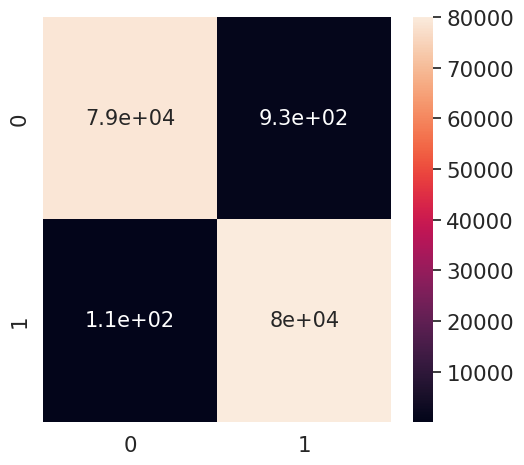

In [57]:
cm = confusion_matrix(y_test_uo, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'dark', font_scale = 1.4)
sns.heatmap(cm, annot = True, annot_kws = {"size": 15})
print("Accuracy: ", model.score(x_test_uo,y_test_uo)*100)

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test_uo, y_pred)  # Precision
recall = recall_score(y_test_uo, y_pred)        # Recall
f1 = f1_score(y_test_uo, y_pred)                # F1-score
y_prob = model.predict_proba(x_test_uo)[:, 1]   # AUC-ROC
auc = roc_auc_score(y_test_uo, y_prob)

print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)

Precision : 0.9885314305466397
Recall : 0.9986032648683701
F1-score : 0.993541823054637
AUC-ROC : 0.9996773067524594


> RandomForest

In [60]:
model = RandomForestClassifier(n_estimators=100, random_state=1,verbose=0 )
model.fit(x_train_uo, y_train_uo)
y_pred = model.predict(x_test_uo)
print("Accuracy: ", model.score(x_test_uo,y_test_uo)*100)

Accuracy:  99.903125


<Axes: >

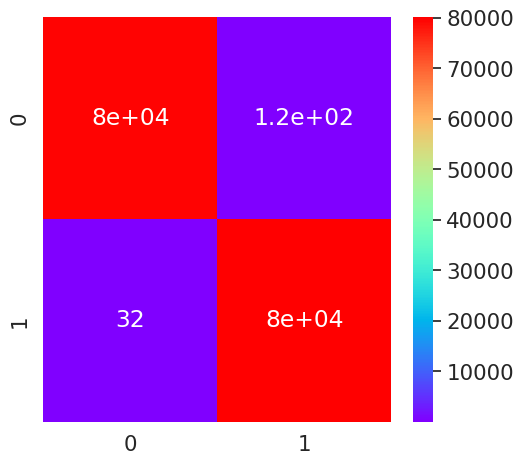

In [61]:
# printing the confusion matrix
cm = confusion_matrix(y_test_uo, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test_uo, y_pred)  # Precision
recall = recall_score(y_test_uo, y_pred)        # Recall
f1 = f1_score(y_test_uo, y_pred)                # F1-score
y_prob = model.predict_proba(x_test_uo)[:, 1]   # AUC-ROC
auc = roc_auc_score(y_test_uo, y_prob)

print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)

Precision : 0.998467824310521
Recall : 0.9996009328195343
F1-score : 0.999034057271056
AUC-ROC : 0.9999729021956901


> LogisticRegression

In [63]:
lr = LogisticRegression(random_state=1)
lr.fit(x_train_uo, y_train_uo)
y_pred = lr.predict(x_test_uo)

print("Accuracy: ", lr.score(x_test_uo,y_test_uo)*100)

Accuracy:  49.883125


<Axes: >

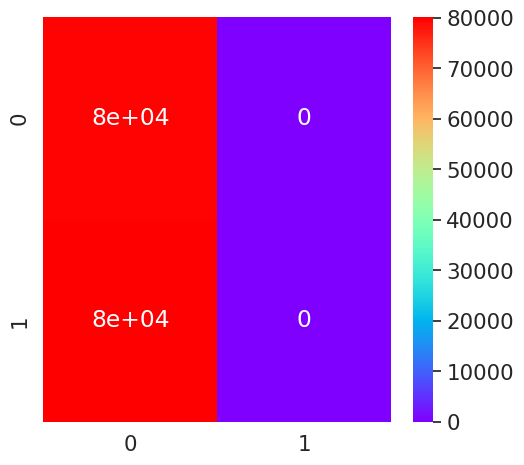

In [64]:
# printing the confusion matrix
cm = confusion_matrix(y_test_uo, y_pred)
sns.heatmap(cm, annot = True, cmap = 'rainbow')

In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test_uo, y_pred)  # Precision
recall = recall_score(y_test_uo, y_pred)        # Recall
f1 = f1_score(y_test_uo, y_pred)                # F1-score
y_prob = model.predict_proba(x_test_uo)[:, 1]   # AUC-ROC
auc = roc_auc_score(y_test_uo, y_prob)

print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Precision : 0.0
Recall : 0.0
F1-score : 0.0
AUC-ROC : 0.9999729021956901


### Feature Importances

In [ ]:
from numpy import loadtxt
from xgboost import XGBClassifier
from xgboost import plot_importance
from matplotlib import pyplot

model = XGBClassifier()
model.fit(x_train_us, y_train_us)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
pio.renderers
pio.renderers.default = 'colab'
pio.renderers

trace = go.Scatter(
    y = model.feature_importances_,
    x = x_train_us.columns.values,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 13,
        color = model.feature_importances_,
        colorscale='Portland',
        showscale=True
    ),
    text = x_train_us.columns.values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Gradient Boosting Model Feature Importance',
    hovermode= 'closest',
     xaxis= dict(
         ticklen= 5,
         showgrid=False,
        zeroline=False,
        showline=False
     ),
    yaxis=dict(
        title= 'Feature Importance',
        showgrid=False,
        zeroline=False,
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter')